In [5]:
%load_ext autoreload
%autoreload 2

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

path = '/home/hz420/python_script/SchwarMAX/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).
    
    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)
    
    # --- Step 1: Compute Sigma_z (Vertical Integration) ---
    
    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)
    
    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
    
    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0
    
    sigma_z2 = (1.0 / nu_val) * integral_val
    
    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)
    
    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)
    
    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR
    
    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)
        
        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)
    
    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)
    
    v_phi_total_sq = term1 + term2 + term3
    
    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R
    
    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))
    
    return output


# @jax.jit
def integrate(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = Nxy.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s

# @jax.jit
def integrate_voronoi(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']
    num_per_bin = dict_data['num_per_bin']
    bin_mapping = dict_data['bin_mapping']
    num_Vbin = dict_data['total_bins']
    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_voronoi, 
                                                     in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        num_Vbin, bin_mapping, num_per_bin,
                        jnp.array([[0,8.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-6.,6.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([60,40]), 360,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = surface_density.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s


# @jax.jit
def integrate_without_binning(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(w0_new, acc_fn, n_steps, dt, initial_time, unroll)
    
    return time, xv

In [46]:
with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(ic['x']), size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]



dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}

N = 20
i = 16
ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

# logL, V_model, sigma_model, h3_model, h4_model = logl(ground_truth, dict_data)
A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

time, xv = integrate_without_binning(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

weights = jnp.array(np.random.uniform(0.5, 1.5, size=xv.shape[0]))
weights_stacked = jnp.repeat(weights[:, jnp.newaxis], xv.shape[1], axis=1)
weights_stacked = weights_stacked.flatten()

10000


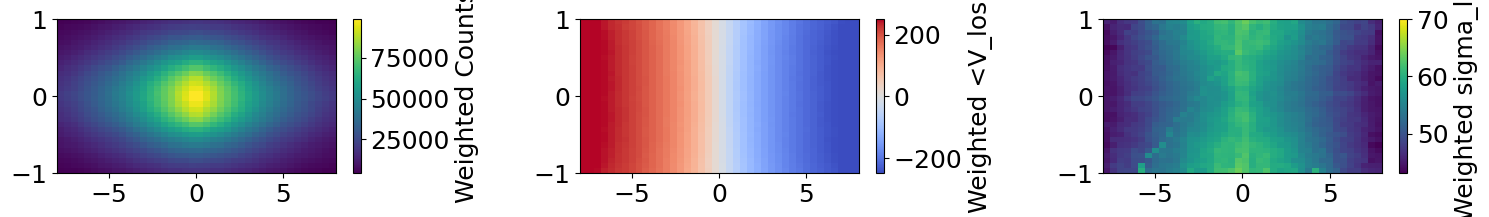

In [37]:

H_weighted, xedge, yedge = np.histogram2d(xv[:,:,0].flatten(), xv[:,:,2].flatten(), bins=(40,30), range=[[-8,8],[-1,1]], weights=weights_stacked)
H_vlos, xedge, yedge = np.histogram2d(xv[:,:,0].flatten(), xv[:,:,2].flatten(), bins=(40,30), range=[[-8,8],[-1,1]], weights=xv[:,:,4].flatten() * weights_stacked)
H_vlos2, xedge, yedge = np.histogram2d(xv[:,:,0].flatten(), xv[:,:,2].flatten(), bins=(40,30), range=[[-8,8],[-1,1]], weights=(xv[:,:,4].flatten()**2) * weights_stacked)
vlos_weighted = H_vlos / (H_weighted + EPSILON)
vlos_std = jnp.sqrt(H_vlos2 / (H_weighted + EPSILON) - vlos_weighted**2)

# weights_stacked.shape

fig1, ax1 = plt.subplots(1, 3, figsize=(18,2), gridspec_kw={'wspace':0.5})
cb = ax1[0].pcolormesh(xedge, yedge, H_weighted.T, cmap='viridis', shading='auto')
fig1.colorbar(cb, ax=ax1[0], label='Weighted Counts')
cb = ax1[1].pcolormesh(xedge, yedge, vlos_weighted.T, cmap='coolwarm', shading='auto', vmin=-250, vmax=250)
fig1.colorbar(cb, ax=ax1[1], label='Weighted <V_los>')
cb = ax1[2].pcolormesh(xedge, yedge, vlos_std.T, cmap='viridis', shading='auto', vmax=70)
fig1.colorbar(cb, ax=ax1[2], label='Weighted sigma_los')

Total counts in XY bins: 1200 and only 1 per bin: True


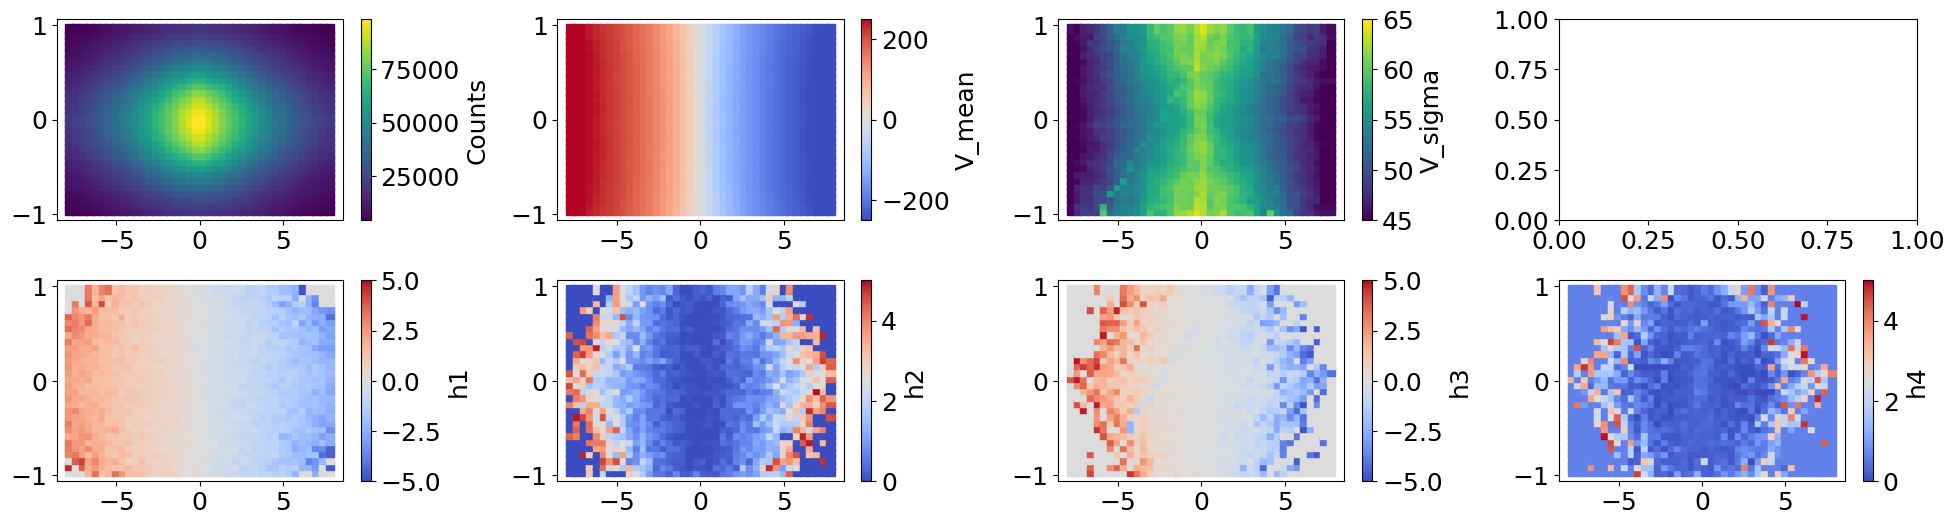

In [47]:
X_min, X_max = -8., 8.
Y_min, Y_max = -1., 1.
nX, nY = 40, 30

X_edge = jnp.linspace(X_min, X_max, nX+1)
Y_edge = jnp.linspace(Y_min, Y_max, nY+1)
X_mids, Y_mids = 0.5 * (X_edge[:-1] + X_edge[1:]), 0.5 * (Y_edge[:-1] + Y_edge[1:])

X_mid_mesh, Y_mids_mesh = jnp.meshgrid(X_mids, Y_mids, indexing='ij')
XY_mid_grid = jnp.stack([X_mid_mesh.ravel(), Y_mids_mesh.ravel()], axis=-1)  # (n_X*n_Y, 2)

XY_minmax=jnp.array([[X_min,X_max],[Y_min,Y_max]])
nXY=jnp.array([nX,nY])
num_segments_XY=nXY.prod()
XY_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_grid_indices = assign_regular_grid(XY_mid_grid,
                                    grid_min=XY_minmax[:,0],
                                    grid_max=XY_minmax[:,1],
                                    n_bins=nXY,
                                    strides=XY_strides)
_, COUNTS_XY = jnp.unique(XY_grid_indices, return_counts=True)
print('Total counts in XY bins:', jnp.sum(COUNTS_XY), 'and only 1 per bin:', jnp.all(COUNTS_XY <= 1))

df_XY = pd.DataFrame({
    'id': XY_grid_indices,
    'X_grid': XY_mid_grid[:,0],
    'Y_grid': XY_mid_grid[:,1],
})

XY_stars = jnp.array([
            xv[:,:,0].flatten(), xv[:,:,2].flatten()
            ]).T  # (n_stars, 2)


XY_strdides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_indices = assign_regular_grid(XY_stars,
                                grid_min=XY_minmax[:,0],
                                grid_max=XY_minmax[:,1],
                                n_bins=nXY,
                                strides=XY_strdides)

vy = xv[:,:,4].flatten()
index = jnp.arange(num_segments_XY)
counts = jax.ops.segment_sum(weights_stacked * jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
V_mean = jax.ops.segment_sum(weights_stacked * vy, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V2_mean = jax.ops.segment_sum(weights_stacked * vy**2, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V_sigma = jnp.sqrt(jnp.clip(V2_mean - V_mean**2, a_min=0.0))

v0_cell = v0[XY_indices]
s_cell = s[XY_indices]

w = (vy - v0_cell) / s_cell # (v_los - v0) / s, where in edge-on case v_los = vy = wN[:,4]
counts = jax.ops.segment_sum(weights_stacked * jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
sum_w1 = jax.ops.segment_sum(weights_stacked * w, XY_indices, num_segments=num_segments_XY)
sum_w2 = jax.ops.segment_sum(weights_stacked * w**2, XY_indices, num_segments=num_segments_XY)
sum_w3 = jax.ops.segment_sum(weights_stacked * w**3, XY_indices, num_segments=num_segments_XY)
sum_w4 = jax.ops.segment_sum(weights_stacked * w**4, XY_indices, num_segments=num_segments_XY)
eps = EPSILON
norm = counts + eps
w1 = sum_w1 / norm
w2 = sum_w2 / norm
w3 = sum_w3 / norm
w4 = sum_w4 / norm

h1 = w1
h2 = ((w2 - 1) / jnp.sqrt(2))
h3 = ((w3 - 3 * w1) / jnp.sqrt(6))
h4 = ((w4 - 6 * w2 + 3) / jnp.sqrt(24))

# N_min = 50
# V_mean = jnp.where(counts < N_min, 0, V_mean)
# V_sigma = jnp.where(counts < N_min, 0, V_sigma)
# h1 = jnp.where(counts < N_min, 0, h1)
# h2 = jnp.where(counts < N_min, -1/jnp.sqrt(2), h2)
# h3 = jnp.where(counts < N_min, 0, h3)
# h4 = jnp.where(counts < N_min, 3/jnp.sqrt(24), h4)
# counts = jnp.where(counts < N_min, 0, counts)
# nonempty_index = counts > N_min #jnp.where(counts > 10)[0]

h1 = jnp.where(jnp.fabs(h1)>5, 0, h1)
h2 = jnp.where(jnp.fabs(h2)>5, -1/jnp.sqrt(2), h2)
h3 = jnp.where(jnp.fabs(h3)>5, 0, h3)
h4 = jnp.where(jnp.fabs(h4)>5, 3/jnp.sqrt(24), h4)

df_XY_moments = pd.DataFrame({
    'id': index,
    'N_count': counts.astype(jnp.float32),
    'V_mean': V_mean,
    'V_sigma': V_sigma,
    'h1': h1,
    'h2': h2,
    'h3': h3,
    'h4': h4,
    'v0_cell': v0,
    's_cell': s,
})
df_XY = df_XY.merge(df_XY_moments, on='id', how='left')

fig2, ax2 = plt.subplots(2,4, figsize=(24,6), gridspec_kw={'wspace':0.4, 'hspace':0.3})
cb = ax2[0,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['N_count'], 
                 marker = 's', cmap='viridis', rasterized = True)
fig2.colorbar(cb, ax=ax2[0,0], label='Counts')
cb = ax2[0,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['V_mean'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin=-250, vmax=250)
fig2.colorbar(cb, ax=ax2[0,1], label='V_mean')
cb = ax2[0,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['V_sigma'], 
                 marker = 's', cmap='viridis', rasterized = True, vmin = 45, vmax = 65)
fig2.colorbar(cb, ax=ax2[0,2], label='V_sigma')
cb = ax2[1,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h1'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,0], label='h1')
cb = ax2[1,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h2'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,1], label='h2')
cb = ax2[1,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h3'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,2], label='h3')
cb = ax2[1,3].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h4'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,3], label='h4')

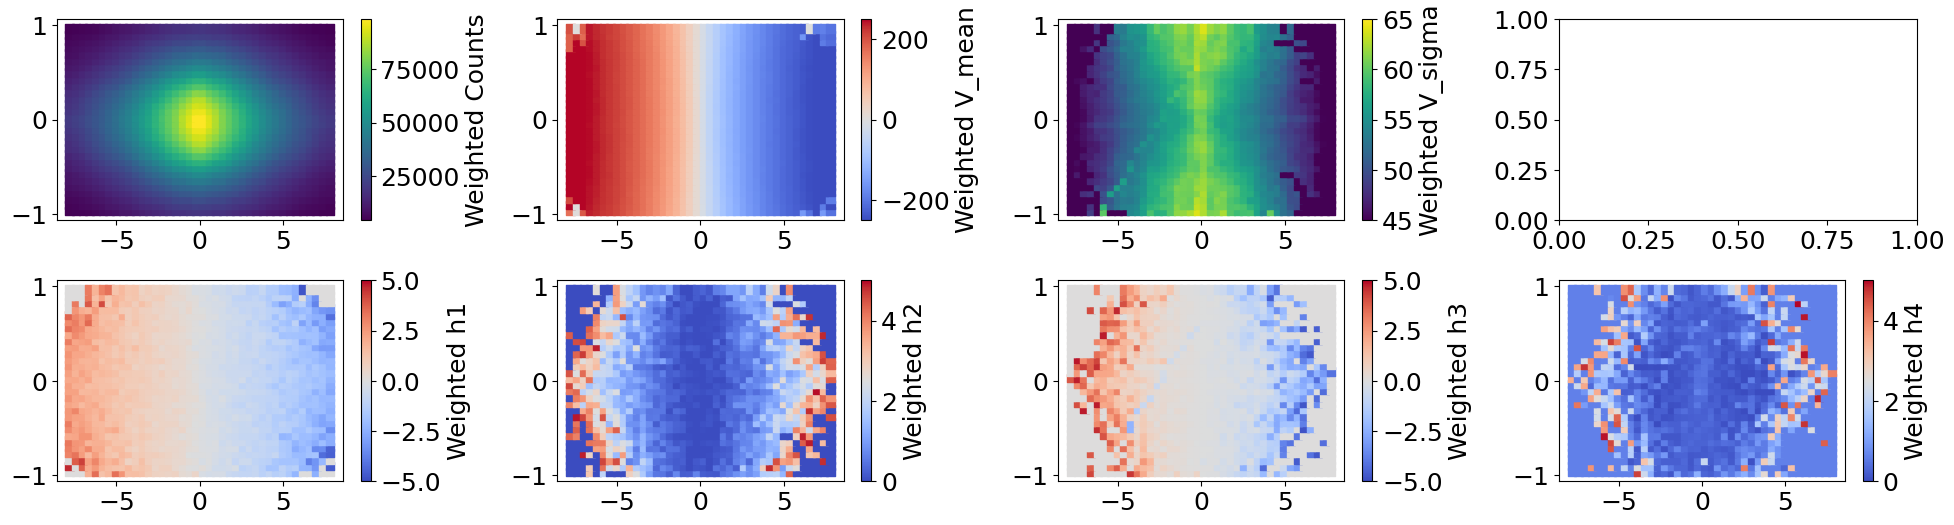

In [48]:
density_2DXY_weighted = 5000 * A_xy @ weights
_A_h1 = A_h1 * A_xy * 5000
_A_h2 = A_h2 * A_xy * 5000
_A_h3 = A_h3 * A_xy * 5000
_A_h4 = A_h4 * A_xy * 5000
h1_model_weighted = (_A_h1 @ weights) / density_2DXY_weighted
h2_model_weighted = (_A_h2 @ weights) / density_2DXY_weighted
h3_model_weighted = (_A_h3 @ weights) / density_2DXY_weighted
h4_model_weighted = (_A_h4 @ weights) / density_2DXY_weighted

h1_model_weighted = jnp.where(jnp.fabs(h1_model_weighted)>5, 0, h1_model_weighted)
h2_model_weighted = jnp.where(jnp.fabs(h2_model_weighted)>5, -1/jnp.sqrt(2), h2_model_weighted)
h3_model_weighted = jnp.where(jnp.fabs(h3_model_weighted)>5, 0, h3_model_weighted)
h4_model_weighted = jnp.where(jnp.fabs(h4_model_weighted)>5, 3/jnp.sqrt(24), h4_model_weighted)

V_model_weighted, sigma_model_weighted = h_to_V_sigma(h1_model_weighted, h2_model_weighted, v0, s)

fig3, ax3 = plt.subplots(2,4, figsize=(24,6), gridspec_kw={'wspace':0.4, 'hspace':0.3})
cb = ax3[0,0].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=density_2DXY_weighted, 
                 marker = 's', cmap='viridis', rasterized = True)
fig3.colorbar(cb, ax=ax3[0,0], label='Weighted Counts')
cb = ax3[0,1].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=V_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin=-250, vmax=250)
fig3.colorbar(cb, ax=ax3[0,1], label='Weighted V_mean')
cb = ax3[0,2].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=sigma_model_weighted, 
                 marker = 's', cmap='viridis', rasterized = True, vmin = 45, vmax = 65)
fig3.colorbar(cb, ax=ax3[0,2], label='Weighted V_sigma')
cb = ax3[1,0].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=h1_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig3.colorbar(cb, ax=ax3[1,0], label='Weighted h1')
cb = ax3[1,1].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=h2_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig3.colorbar(cb, ax=ax3[1,1], label='Weighted h2')
cb = ax3[1,2].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=h3_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig3.colorbar(cb, ax=ax3[1,2], label='Weighted h3')
cb = ax3[1,3].scatter(df_XY_data['X_grid'], df_XY_data['Y_grid'], c=h4_model_weighted, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig3.colorbar(cb, ax=ax3[1,3], label='Weighted h4') 

In [3]:

# @jax.jit
def integrate_voronoi(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']
    num_per_bin = dict_data['num_per_bin']
    bin_mapping = dict_data['bin_mapping']
    num_Vbin = dict_data['total_bins']
    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_voronoi, 
                                                     in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        num_Vbin, bin_mapping, num_per_bin,
                        jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]]), jnp.array([[-10.,10.],[-3.,3.]]),
                        jnp.array([10,6,6]), jnp.array([60,40]), 360,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = surface_density.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s


In [4]:
df_ic = pd.read_csv(path + 'mock_initial_conditions_xyz.csv')
df_ic = df_ic[np.sqrt(df_ic['x']**2 + df_ic['y']**2) < 10.0]
df_ic = df_ic[np.fabs(df_ic['z']) < 3.0]

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(df_ic['x']), size=n_particles, replace=False)
df_ic = df_ic.iloc[index]
# w0 = jnp.array([df_ic['x'], df_ic['y'], df_ic['z'], df_ic['vx'], df_ic['vy'], df_ic['vz']]).T
w0 = jnp.array(df_ic[['x','y','z']].to_numpy())


with open(path + 'mock_axisymmetric_disc_XY_voronoi.pkl', 'rb') as f:
    bin_dict = pickle.load(f)

# regular grid parameters
nX, nY = bin_dict['nX_nY']
X_min, X_max = bin_dict['X_minmax']
Y_min, Y_max = bin_dict['Y_minmax']
X_regular_grid = bin_dict['X_regular_grid']
Y_regular_grid = bin_dict['Y_regular_grid']

# voronoi binning mapping and data
xy_vbins = bin_dict['voronoi_bins_xy']
num_per_bin = jnp.array(bin_dict['num_per_bin'])
total_bins = jnp.array(bin_dict['total_bins'])
bin_mapping = jnp.array(bin_dict['bin_mapping'])
surface_density = jnp.array(bin_dict['surface_density'])
V_data = jnp.array(bin_dict['V_mean'])
sigma_data = jnp.array(bin_dict['V_sigma'])
h1_data = jnp.array(bin_dict['h1'])
h2_data = jnp.array(bin_dict['h2'])
h3_data = jnp.array(bin_dict['h3'])
h4_data = jnp.array(bin_dict['h4'])
v0 = jnp.array(bin_dict['v0'])
s = jnp.array(bin_dict['s'])

V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.01, 0.01, 0.1 * jnp.fabs(h1_data))
h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.01, 0.01, 0.1 * jnp.fabs(h2_data))
h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.01, 0.01, 0.1 * jnp.fabs(h3_data))
h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.01, 0.01, 0.1 * jnp.fabs(h4_data))

# df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
# Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)


dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    # 'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': surface_density,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'num_per_bin': num_per_bin,
    'bin_mapping': bin_mapping,
    'total_bins': total_bins.item()
}


with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

N = 20
i = 11
ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
}
# ground_truth = {
#         'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
#         'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
#         'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
#         'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
#         'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
# }

params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

# logL, V_model, sigma_model, h3_model, h4_model = logl(ground_truth, dict_data)
A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate_voronoi(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

# time, xv = integrate_without_binning(
#     params_halo_pot,
#     params_disk_rho,
#     dict_data
# )

# weights = jnp.array(np.random.uniform(0.5, 1.5, size=xv.shape[0]))
weights = jnp.array(np.random.uniform(0.99, 1.01, size=A_xy.shape[1]))
weights_stacked = jnp.repeat(weights[:, jnp.newaxis], A_xy.shape[1], axis=1)
weights_stacked = weights_stacked.flatten()

A_Rzphi.block_until_ready()

10000


Array([[0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.0036, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.013 , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       ...,
       [0.    , 0.0026, 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.0016, 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ]],      dtype=float32)

In [6]:
A_xy.shape

(1055, 10000)

In [113]:
total_bins

Array(1055, dtype=int32)

In [120]:
bin_mapping.shape

(2401,)

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3542972/159803802.py:45: SyntaxWarning: invalid escape sequence '\s'
  fig1.colorbar(cb3, ax=ax1[0,2], label='$\sigma_V$ [km/s]')
/tmp/ipykernel_3542972/159803802.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax1[0,2].set_title('$\sigma_V$')


Text(0, 0.5, 'Y [kpc]')

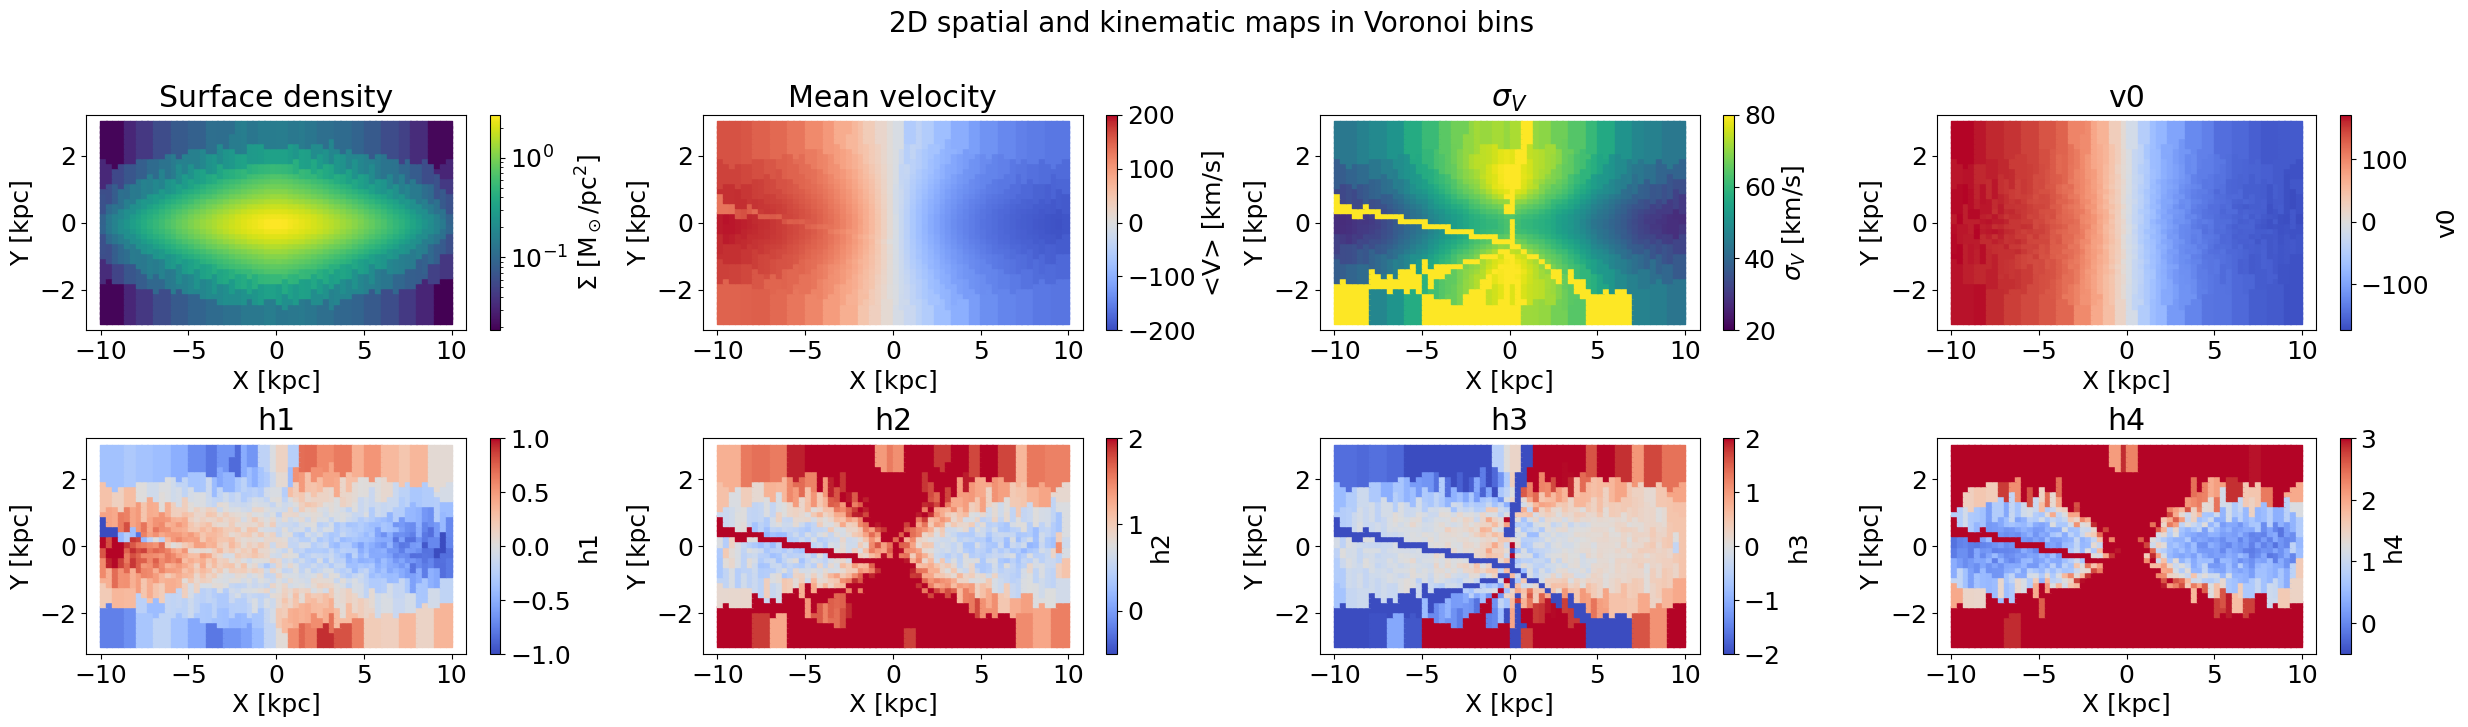

In [33]:
_A_xy = A_xy * 5000
density_2DXY_weighted = _A_xy @ weights
_A_h1 = A_h1 * _A_xy
_A_h2 = A_h2 * _A_xy
_A_h3 = A_h3 * _A_xy
_A_h4 = A_h4 * _A_xy
h1_model_weighted = (_A_h1 @ weights) / density_2DXY_weighted
h2_model_weighted = (_A_h2 @ weights) / density_2DXY_weighted
h3_model_weighted = (_A_h3 @ weights) / density_2DXY_weighted
h4_model_weighted = (_A_h4 @ weights) / density_2DXY_weighted

# h1_model_weighted = jnp.where(jnp.fabs(h1_model_weighted)>5, 0, h1_model_weighted)
# h2_model_weighted = jnp.where(jnp.fabs(h2_model_weighted)>5, -1/jnp.sqrt(2), h2_model_weighted)
# h3_model_weighted = jnp.where(jnp.fabs(h3_model_weighted)>5, 0, h3_model_weighted)
# h4_model_weighted = jnp.where(jnp.fabs(h4_model_weighted)>5, 3/jnp.sqrt(24), h4_model_weighted)

V_model_weighted, sigma_model_weighted = h_to_V_sigma(h1_model_weighted, h2_model_weighted, v0, s)

index_remap = bin_mapping[:-1]

density_2DXY_weighted = density_2DXY_weighted[index_remap]
V_model_weighted = V_model_weighted[index_remap]
sigma_model_weighted = sigma_model_weighted[index_remap]
h1_model_weighted = h1_model_weighted[index_remap]
h2_model_weighted = h2_model_weighted[index_remap]
h3_model_weighted = h3_model_weighted[index_remap]
h4_model_weighted = h4_model_weighted[index_remap]

fig1,ax1 = plt.subplots(2,4,figsize=(30,7), gridspec_kw={'hspace':0.5, 'wspace':0.3})
fig1.suptitle('2D spatial and kinematic maps in Voronoi bins', fontsize=20, y = 1.03)
cb1 = ax1[0,0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted, 
                s = 20, cmap='viridis', marker = 's', norm = 'log')
fig1.colorbar(cb1, ax=ax1[0,0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')
ax1[0,0].set_title('Surface density')
ax1[0,0].set_xlabel('X [kpc]')
ax1[0,0].set_ylabel('Y [kpc]')
cb2 = ax1[0,1].scatter(X_regular_grid, Y_regular_grid, c=V_model_weighted, 
                s = 20, cmap='coolwarm', marker = 's', vmin = -200, vmax=200)
fig1.colorbar(cb2, ax=ax1[0,1], label='<V> [km/s]')
ax1[0,1].set_title('Mean velocity')
ax1[0,1].set_xlabel('X [kpc]')
ax1[0,1].set_ylabel('Y [kpc]')
cb3 = ax1[0,2].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_weighted, 
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax=80)
fig1.colorbar(cb3, ax=ax1[0,2], label='$\sigma_V$ [km/s]')
ax1[0,2].set_title('$\sigma_V$')
ax1[0,2].set_xlabel('X [kpc]')
ax1[0,2].set_ylabel('Y [kpc]')

cb4 = ax1[1,0].scatter(X_regular_grid, Y_regular_grid, c=h1_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -1, vmax=1)
fig1.colorbar(cb4, ax=ax1[1,0], label='h1')
ax1[1,0].set_title('h1')
ax1[1,0].set_xlabel('X [kpc]')
ax1[1,0].set_ylabel('Y [kpc]')
cb5 = ax1[1,1].scatter(X_regular_grid, Y_regular_grid, c=h2_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax=2)
fig1.colorbar(cb5, ax=ax1[1,1], label='h2')
ax1[1,1].set_title('h2')
ax1[1,1].set_xlabel('X [kpc]')
ax1[1,1].set_ylabel('Y [kpc]')
cb6 = ax1[1,2].scatter(X_regular_grid, Y_regular_grid, c=h3_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -2, vmax=2)
fig1.colorbar(cb6, ax=ax1[1,2], label='h3')
ax1[1,2].set_title('h3')
ax1[1,2].set_xlabel('X [kpc]')
ax1[1,2].set_ylabel('Y [kpc]')
cb7 = ax1[1,3].scatter(X_regular_grid, Y_regular_grid, c=h4_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax=3)
fig1.colorbar(cb7, ax=ax1[1,3], label='h4')
ax1[1,3].set_title('h4')
ax1[1,3].set_xlabel('X [kpc]')
ax1[1,3].set_ylabel('Y [kpc]')

cb7 = ax1[0,3].scatter(X_regular_grid, Y_regular_grid, c=v0[index_remap],
                s = 20, cmap='coolwarm', marker = 's')
fig1.colorbar(cb7, ax=ax1[0,3], label='v0')
ax1[0,3].set_title('v0')
ax1[0,3].set_xlabel('X [kpc]')
ax1[0,3].set_ylabel('Y [kpc]')

# Add orientation

In [7]:
help(makeRotationMatrix)

Help on function makeRotationMatrix in module utils:

makeRotationMatrix(alpha, beta, gamma)



In [ ]:

# @jax.jit
def integrate_rot(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']
    num_per_bin = dict_data['num_per_bin']
    bin_mapping = dict_data['bin_mapping']
    num_Vbin = dict_data['total_bins']

    alpha, beta, gamma = params_disk_rho['alpha'], params_disk_rho['beta'], params_disk_rho['gamma']
    rotation_matrix = makeRotationMatrix(alpha, beta, gamma)
    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_rot, 
                                                     in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        num_Vbin, bin_mapping, num_per_bin,
                        jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]]), jnp.array([[-12.,12.],[-4.,4.]]),
                        jnp.array([10,6,6]), jnp.array([60,40]), 360,
                        v0, s, rotation_matrix)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = surface_density.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s


In [10]:


df_ic = pd.read_csv(path + 'mock_initial_conditions_xyz.csv')
df_ic = df_ic[np.sqrt(df_ic['x']**2 + df_ic['y']**2) < 10.0]
df_ic = df_ic[np.fabs(df_ic['z']) < 3.0]

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(df_ic['x']), size=n_particles, replace=False)
df_ic = df_ic.iloc[index]
# w0 = jnp.array([df_ic['x'], df_ic['y'], df_ic['z'], df_ic['vx'], df_ic['vy'], df_ic['vz']]).T
w0 = jnp.array(df_ic[['x','y','z']].to_numpy())


with open(path + 'mock_axisymmetric_disc_XY_withRot.pkl', 'rb') as f:
    bin_dict = pickle.load(f)

# regular grid parameters
nX, nY = bin_dict['nX_nY']
X_min, X_max = bin_dict['X_minmax']
Y_min, Y_max = bin_dict['Y_minmax']
X_regular_grid = bin_dict['X_regular_grid']
Y_regular_grid = bin_dict['Y_regular_grid']

# voronoi binning mapping and data
xy_vbins = bin_dict['voronoi_bins_xy']
num_per_bin = jnp.array(bin_dict['num_per_bin'])
total_bins = jnp.array(bin_dict['total_bins'])
bin_mapping = jnp.array(bin_dict['bin_mapping'])
surface_density = jnp.array(bin_dict['surface_density'])
V_data = jnp.array(bin_dict['V_mean'])
sigma_data = jnp.array(bin_dict['V_sigma'])
h1_data = jnp.array(bin_dict['h1'])
h2_data = jnp.array(bin_dict['h2'])
h3_data = jnp.array(bin_dict['h3'])
h4_data = jnp.array(bin_dict['h4'])
v0 = jnp.array(bin_dict['v0'])
s = jnp.array(bin_dict['s'])
alpha, beta, gamma = bin_dict['orientation']

V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.01, 0.01, 0.1 * jnp.fabs(h1_data))
h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.01, 0.01, 0.1 * jnp.fabs(h2_data))
h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.01, 0.01, 0.1 * jnp.fabs(h3_data))
h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.01, 0.01, 0.1 * jnp.fabs(h4_data))

# df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
# Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)


dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    # 'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': surface_density,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'num_per_bin': num_per_bin,
    'bin_mapping': bin_mapping,
    'total_bins': total_bins.item()
}


with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

N = 20
i = 11
ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
}
# ground_truth = {
#         'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
#         'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
#         'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
#         'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
#         'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
# }

params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0,
    'alpha': alpha,
    'beta': beta,
    'gamma': gamma
}

# # logL, V_model, sigma_model, h3_model, h4_model = logl(ground_truth, dict_data)
A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate_rot(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

# # time, xv = integrate_without_binning(
# #     params_halo_pot,
# #     params_disk_rho,
# #     dict_data
# # )

# weights = jnp.array(np.random.uniform(0.5, 1.5, size=xv.shape[0]))
weights = jnp.array(np.random.uniform(0.99, 1.01, size=A_xy.shape[1]))
weights_stacked = jnp.repeat(weights[:, jnp.newaxis], A_xy.shape[1], axis=1)
weights_stacked = weights_stacked.flatten()

A_Rzphi.block_until_ready()

10000


Array([[0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.0006, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       ...,
       [0.    , 0.0026, 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.0004, 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ]],      dtype=float32)

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3164559/159803802.py:45: SyntaxWarning: invalid escape sequence '\s'
  fig1.colorbar(cb3, ax=ax1[0,2], label='$\sigma_V$ [km/s]')
/tmp/ipykernel_3164559/159803802.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax1[0,2].set_title('$\sigma_V$')


Text(0, 0.5, 'Y [kpc]')

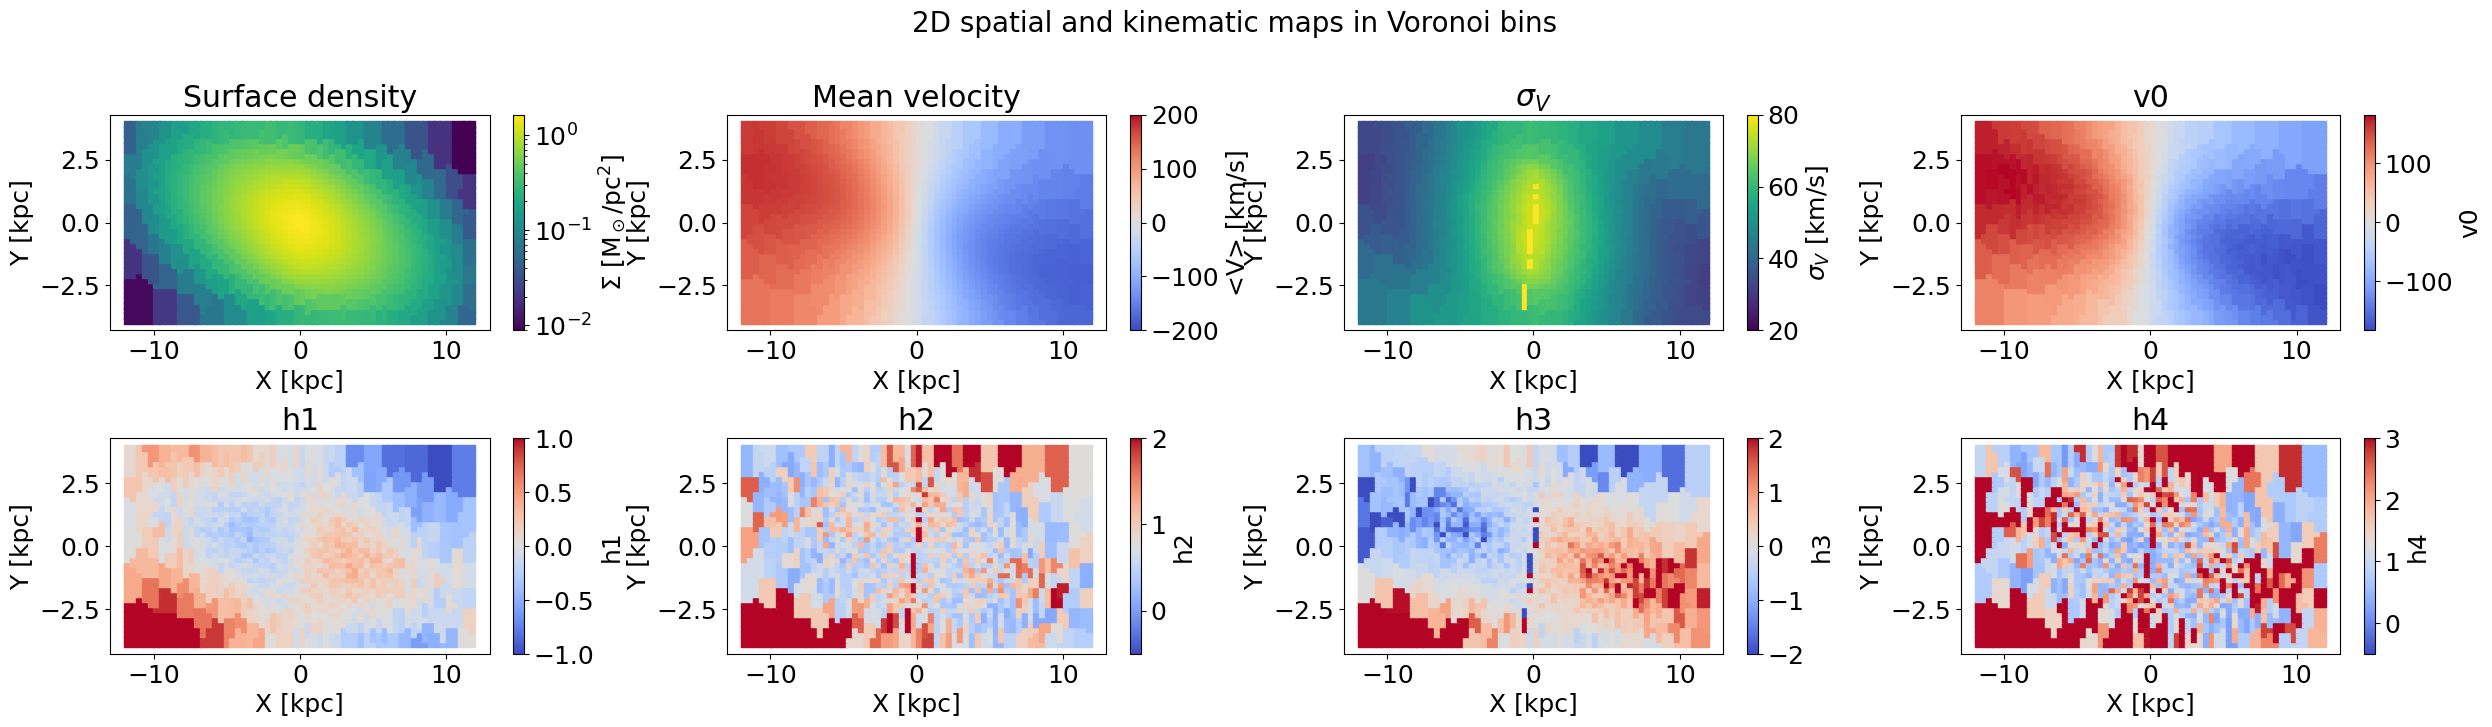

In [ ]:
_A_xy = A_xy * 5000
density_2DXY_weighted = _A_xy @ weights
_A_h1 = A_h1 * _A_xy
_A_h2 = A_h2 * _A_xy
_A_h3 = A_h3 * _A_xy
_A_h4 = A_h4 * _A_xy
h1_model_weighted = (_A_h1 @ weights) / density_2DXY_weighted
h2_model_weighted = (_A_h2 @ weights) / density_2DXY_weighted
h3_model_weighted = (_A_h3 @ weights) / density_2DXY_weighted
h4_model_weighted = (_A_h4 @ weights) / density_2DXY_weighted

# h1_model_weighted = jnp.where(jnp.fabs(h1_model_weighted)>5, 0, h1_model_weighted)
# h2_model_weighted = jnp.where(jnp.fabs(h2_model_weighted)>5, -1/jnp.sqrt(2), h2_model_weighted)
# h3_model_weighted = jnp.where(jnp.fabs(h3_model_weighted)>5, 0, h3_model_weighted)
# h4_model_weighted = jnp.where(jnp.fabs(h4_model_weighted)>5, 3/jnp.sqrt(24), h4_model_weighted)

V_model_weighted, sigma_model_weighted = h_to_V_sigma(h1_model_weighted, h2_model_weighted, v0, s)

index_remap = bin_mapping[:-1]

density_2DXY_weighted = density_2DXY_weighted[index_remap]
V_model_weighted = V_model_weighted[index_remap]
sigma_model_weighted = sigma_model_weighted[index_remap]
h1_model_weighted = h1_model_weighted[index_remap]
h2_model_weighted = h2_model_weighted[index_remap]
h3_model_weighted = h3_model_weighted[index_remap]
h4_model_weighted = h4_model_weighted[index_remap]

fig1,ax1 = plt.subplots(2,4,figsize=(30,7), gridspec_kw={'hspace':0.5, 'wspace':0.3})
fig1.suptitle('2D spatial and kinematic maps in Voronoi bins', fontsize=20, y = 1.03)
cb1 = ax1[0,0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted, 
                s = 20, cmap='viridis', marker = 's', norm = 'log')
fig1.colorbar(cb1, ax=ax1[0,0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')
ax1[0,0].set_title('Surface density')
ax1[0,0].set_xlabel('X [kpc]')
ax1[0,0].set_ylabel('Y [kpc]')
cb2 = ax1[0,1].scatter(X_regular_grid, Y_regular_grid, c=V_model_weighted, 
                s = 20, cmap='coolwarm', marker = 's', vmin = -200, vmax=200)
fig1.colorbar(cb2, ax=ax1[0,1], label='<V> [km/s]')
ax1[0,1].set_title('Mean velocity')
ax1[0,1].set_xlabel('X [kpc]')
ax1[0,1].set_ylabel('Y [kpc]')
cb3 = ax1[0,2].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_weighted, 
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax=80)
fig1.colorbar(cb3, ax=ax1[0,2], label='$\sigma_V$ [km/s]')
ax1[0,2].set_title('$\sigma_V$')
ax1[0,2].set_xlabel('X [kpc]')
ax1[0,2].set_ylabel('Y [kpc]')

cb4 = ax1[1,0].scatter(X_regular_grid, Y_regular_grid, c=h1_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -1, vmax=1)
fig1.colorbar(cb4, ax=ax1[1,0], label='h1')
ax1[1,0].set_title('h1')
ax1[1,0].set_xlabel('X [kpc]')
ax1[1,0].set_ylabel('Y [kpc]')
cb5 = ax1[1,1].scatter(X_regular_grid, Y_regular_grid, c=h2_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax=2)
fig1.colorbar(cb5, ax=ax1[1,1], label='h2')
ax1[1,1].set_title('h2')
ax1[1,1].set_xlabel('X [kpc]')
ax1[1,1].set_ylabel('Y [kpc]')
cb6 = ax1[1,2].scatter(X_regular_grid, Y_regular_grid, c=h3_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -2, vmax=2)
fig1.colorbar(cb6, ax=ax1[1,2], label='h3')
ax1[1,2].set_title('h3')
ax1[1,2].set_xlabel('X [kpc]')
ax1[1,2].set_ylabel('Y [kpc]')
cb7 = ax1[1,3].scatter(X_regular_grid, Y_regular_grid, c=h4_model_weighted,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax=3)
fig1.colorbar(cb7, ax=ax1[1,3], label='h4')
ax1[1,3].set_title('h4')
ax1[1,3].set_xlabel('X [kpc]')
ax1[1,3].set_ylabel('Y [kpc]')

cb7 = ax1[0,3].scatter(X_regular_grid, Y_regular_grid, c=v0[index_remap],
                s = 20, cmap='coolwarm', marker = 's')
fig1.colorbar(cb7, ax=ax1[0,3], label='v0')
ax1[0,3].set_title('v0')
ax1[0,3].set_xlabel('X [kpc]')
ax1[0,3].set_ylabel('Y [kpc]')

# Verify the potential

In [ ]:
import agama
agama.setUnits(mass=1, length=1, velocity=1)

from integrants_with_binning import integrate_leapfrog_barred
from sample_from_density import sample_from_density_grid
from densities import *
from potentials import *
from utils import *
from model import *
from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import pandas as pd
import pickle

import time

def getCylindricalFromCartesian_clockwise(x, y, vx, vy):
    R = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    vR = (x*vx + y*vy) / R
    vphi = -(x*vy - y*vx) / R
    return R, phi, vR, vphi

@jax.jit
def Dehnen_density(x, y, z, params):

    '''
    Dehnen profile: rho = (M / (4π p q Rs^3)) * (r/Rs)^(-n) * (1 + r/Rs)^(n-4), where n = 2
    '''

    p, q, Rs = params['p_bar'], params['q_bar'], params['Rs_bar']
    M = 10.0 ** params['logM_bar']
    r = jnp.sqrt(x**2 + (y / p)**2 + (z / q)**2)

    val = M / (4 * jnp.pi * p * q * Rs**3) * (r / Rs)**(-2) * (1 + r / Rs)**(-2) * jnp.exp(-(z / 3)**4) * jnp.exp(-(r / 10)**4)

    return val

def density_func(x, y, z, params):
    return DoubleExponentialDisk_density(x, y, z, params) + Dehnen_density(x, y, z, params)

def density_func_agama(x):
    return np.array(density_func(x[:, 0], x[:, 1], x[:, 2], params_dict))

params_dict = {
    'rho0_disc': 1e9,
    'Rd_disc': 3.0,
    'hz_disc': 0.3,
    'logM_bar': 10.,
    'Rs_bar': 5.0,
    'q_bar': 0.3,
    'p_bar':0.3,
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0,
}

params_disk_rho = params_dict
NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 50, 1e-3, 30.0, 1e-3, 15.0, 5.
Nphi = 500
N_int = 10_000
time_start = time.time()
dict_phi = get_phi_m(density_func, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)
# dict_phi.block_until_ready()  # Ensure computation is complete before timing
time_end = time.time()
print(f"Time taken to compute phi_m: {time_end - time_start:.2f} seconds")

x_c, y_c = np.linspace(-10, 10, 100), np.linspace(-10, 10, 100)
X_c, Y_c = np.meshgrid(x_c, y_c)
X_c, Y_c = X_c.flatten(), Y_c.flatten()
Z_c = np.ones_like(X_c) * 1e-1

pts = np.array([X_c, Y_c, Z_c]).T
get_acc_vec = jax.vmap(get_acc, in_axes=(0,0,0,None))
time_start = time.time()
acc_pts_us = get_acc_vec(pts[:,0], pts[:,1], pts[:,2], dict_phi)
acc_pts_us.block_until_ready()  # Ensure computation is complete before timing
time_end = time.time()
print(f"Time taken to compute acceleration (us): {time_end - time_start:.2f} seconds") 
R, phi, F_R, F_phi = getCylindricalFromCartesian_clockwise(pts[:,0], pts[:,1], acc_pts_us[:,0], acc_pts_us[:,1])
acc_pts_us = acc_pts_us.at[:,0].set(F_R)
acc_pts_us = acc_pts_us.at[:,1].set(F_phi)

disc_density_agama = agama.Potential(type = 'Cylspline', density = density_func_agama, symmetry = 'Triaxial', 
                                     Rmin = 0.1, Rmax = 30, zmin = 0.01, zmax=15, mmax=8)
time_start = time.time()
acc_pts_agama = disc_density_agama.force(pts)
time_end = time.time()
print(f"Time taken to compute acceleration (agama): {time_end - time_start:.2f} seconds")
R, phi, F_R, F_phi = getCylindricalFromCartesian_clockwise(pts[:,0], pts[:,1], acc_pts_agama[:,0], acc_pts_agama[:,1])
acc_pts_agama[:,0] = F_R
acc_pts_agama[:,1] = F_phi

relative_difference = (np.fabs(acc_pts_agama - acc_pts_us) / np.fabs(acc_pts_agama)).sum()
print('fractional difference:', relative_difference)


Time taken to compute phi_m: 3.48 seconds
Time taken to compute acceleration (us): 1.01 seconds
Time taken to compute acceleration (agama): 0.00 seconds
fractional difference: 7035.658394704364


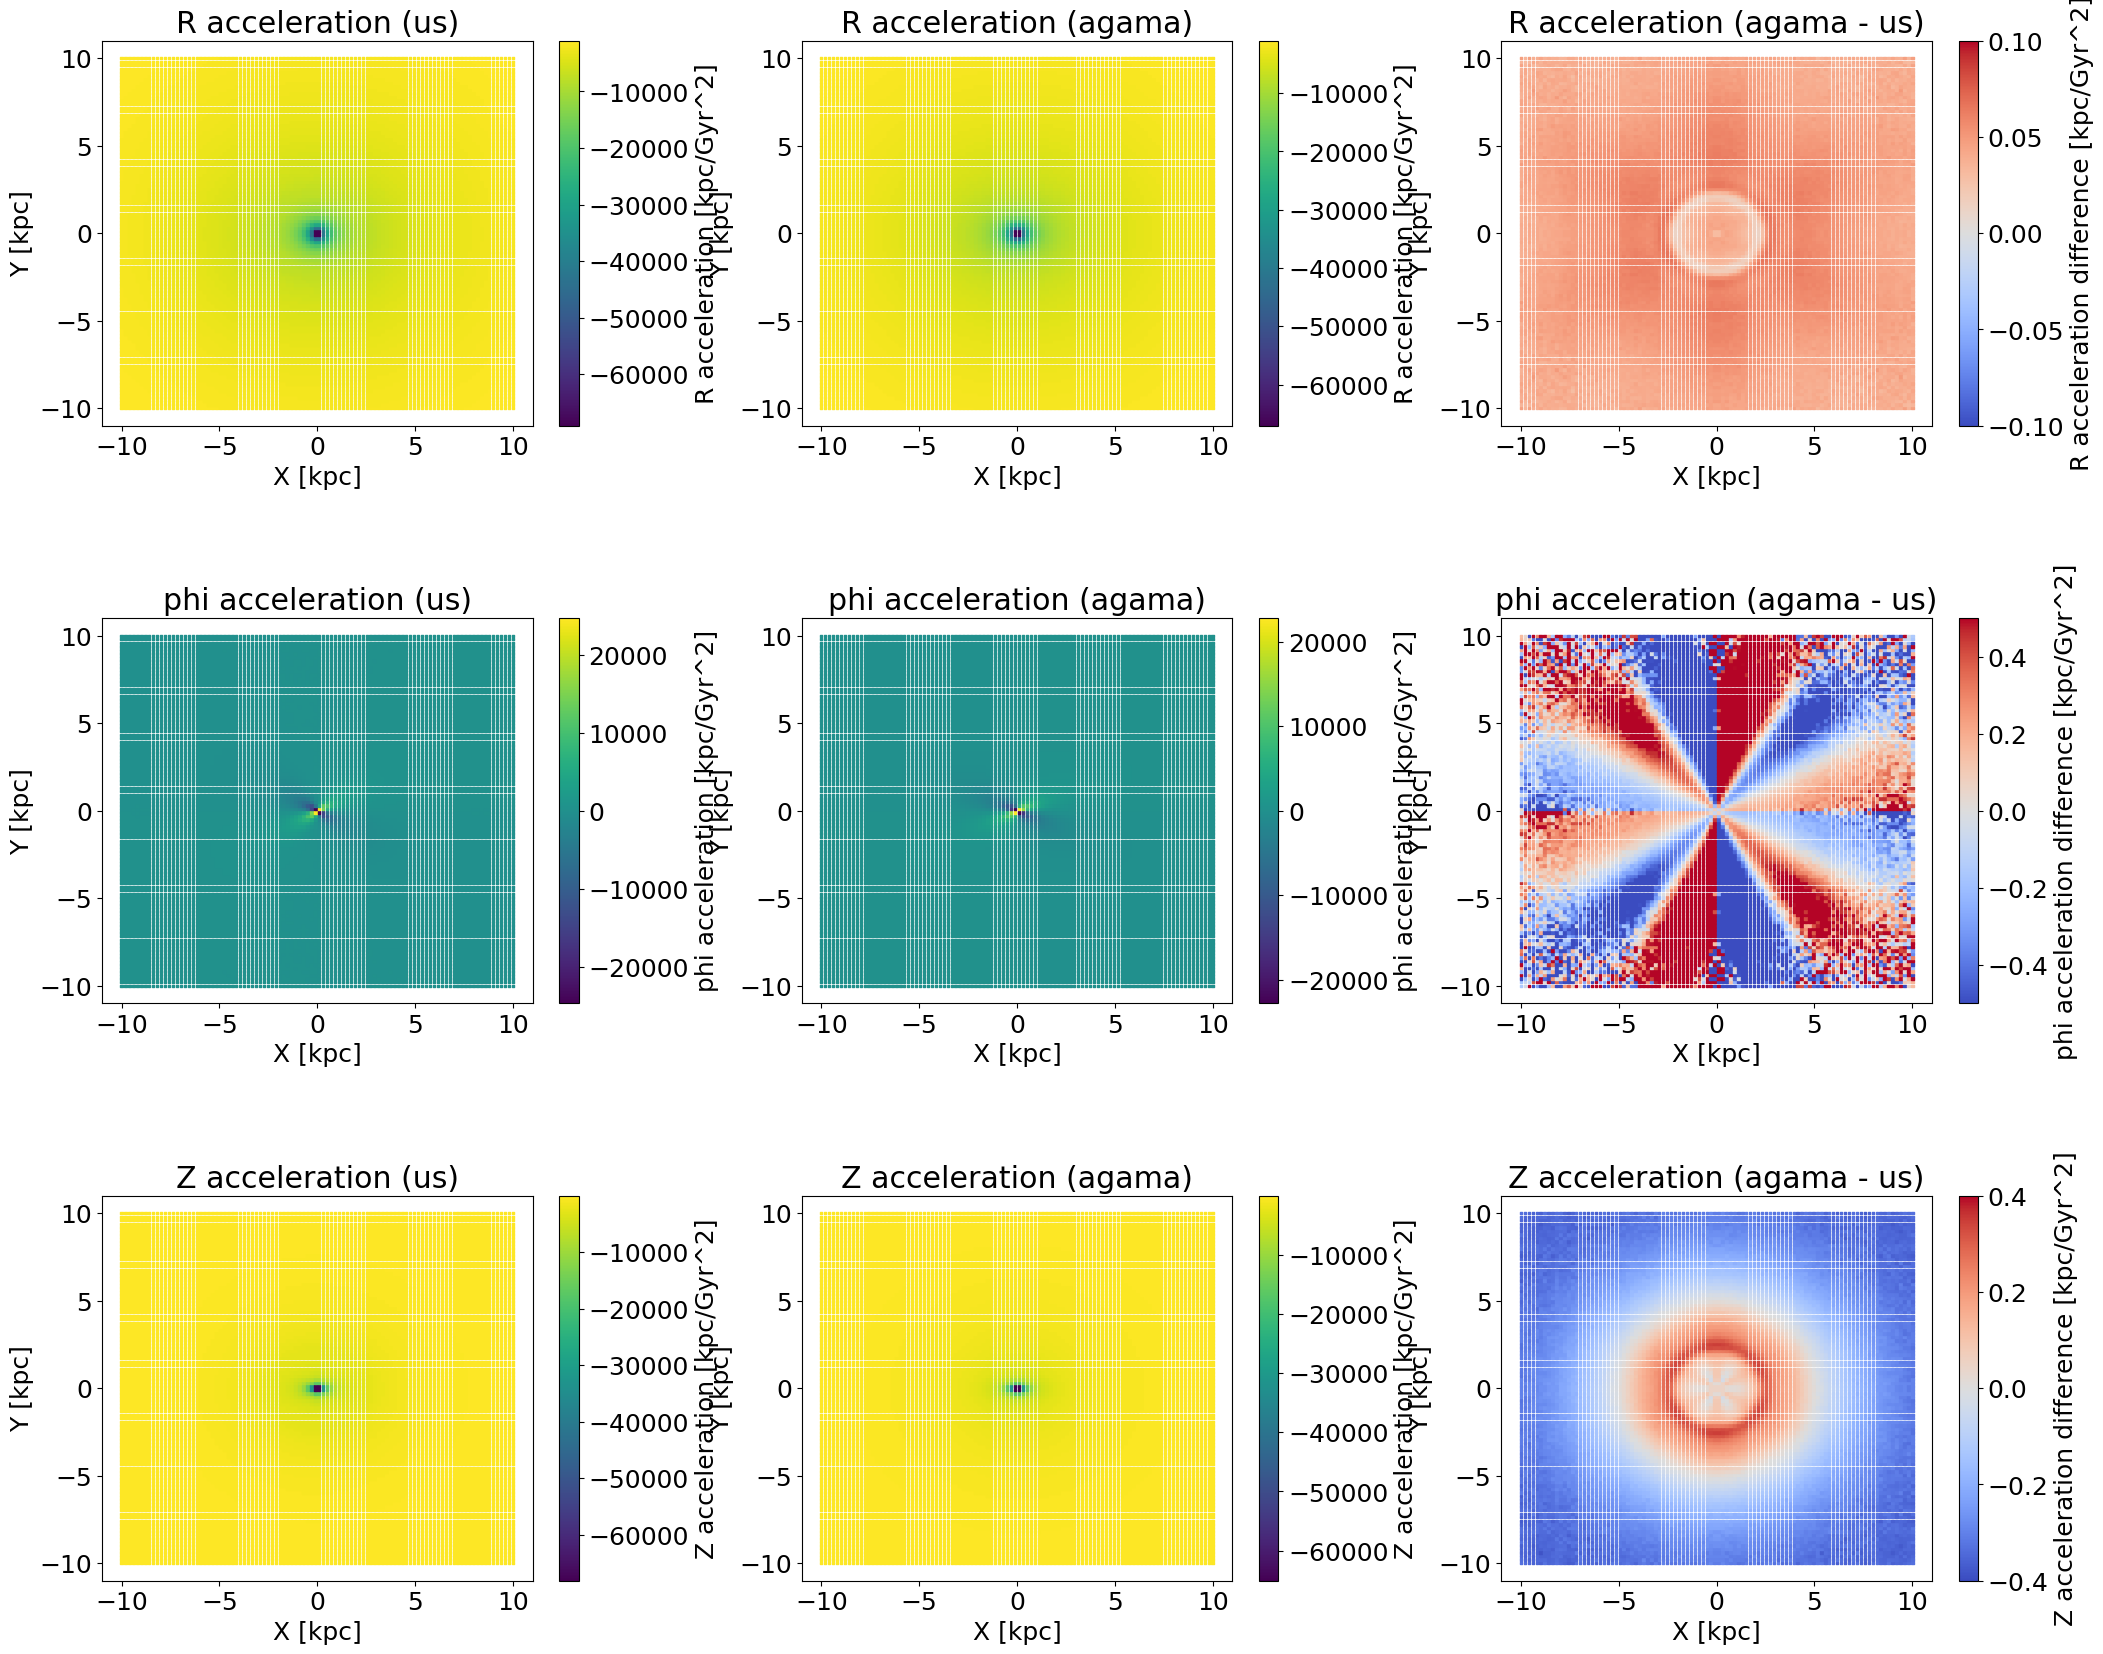

In [243]:
fig, ax = plt.subplots(3,3, figsize=(25,20), gridspec_kw={'hspace':0.5, 'wspace':0.3})
cb = ax[0,0].scatter(X_c, Y_c, c=acc_pts_us[:,0], s=3, marker = 's', cmap='viridis')
plt.colorbar(cb, ax=ax[0,0], label='R acceleration [kpc/Gyr^2]')
ax[0,0].set_title('R acceleration (us)')
ax[0,0].set_xlabel('X [kpc]')
ax[0,0].set_ylabel('Y [kpc]')
cb = ax[0,1].scatter(X_c, Y_c, c=acc_pts_agama[:,0], s=3, marker = 's', cmap='viridis')
plt.colorbar(cb, ax=ax[0,1], label='R acceleration [kpc/Gyr^2]')
ax[0,1].set_title('R acceleration (agama)')
ax[0,1].set_xlabel('X [kpc]')
ax[0,1].set_ylabel('Y [kpc]')
res = (acc_pts_agama[:,0] - acc_pts_us[:,0]) / np.fabs(acc_pts_agama[:,0])
cb = ax[0,2].scatter(X_c, Y_c, c=res, s=3, marker = 's', cmap='coolwarm', vmin = -0.1, vmax = 0.1)
plt.colorbar(cb, ax=ax[0,2], label='R acceleration difference [kpc/Gyr^2]')
ax[0,2].set_title('R acceleration (agama - us)')
ax[0,2].set_xlabel('X [kpc]')
ax[0,2].set_ylabel('Y [kpc]')

cb = ax[1,0].scatter(X_c, Y_c, c=acc_pts_us[:,1], s=3, marker = 's', cmap='viridis')
plt.colorbar(cb, ax=ax[1,0], label='phi acceleration [kpc/Gyr^2]')
ax[1,0].set_title('phi acceleration (us)')
ax[1,0].set_xlabel('X [kpc]')
ax[1,0].set_ylabel('Y [kpc]')
cb = ax[1,1].scatter(X_c, Y_c, c=acc_pts_agama[:,1], s=3, marker = 's', cmap='viridis')
plt.colorbar(cb, ax=ax[1,1], label='phi acceleration [kpc/Gyr^2]')
ax[1,1].set_title('phi acceleration (agama)')
ax[1,1].set_xlabel('X [kpc]')
ax[1,1].set_ylabel('Y [kpc]')
res = (acc_pts_agama[:,1] - acc_pts_us[:,1]) / np.fabs(acc_pts_agama[:,1])
cb = ax[1,2].scatter(X_c, Y_c, c=res, s=3, marker = 's', cmap='coolwarm', vmin = -0.5, vmax = 0.5)
plt.colorbar(cb, ax=ax[1,2], label='phi acceleration difference [kpc/Gyr^2]')
ax[1,2].set_title('phi acceleration (agama - us)')
ax[1,2].set_xlabel('X [kpc]')
ax[1,2].set_ylabel('Y [kpc]')

cb = ax[2,0].scatter(X_c, Y_c, c=acc_pts_us[:,2], s=3, marker = 's', cmap='viridis')
plt.colorbar(cb, ax=ax[2,0], label='Z acceleration [kpc/Gyr^2]')
ax[2,0].set_title('Z acceleration (us)')
ax[2,0].set_xlabel('X [kpc]')
ax[2,0].set_ylabel('Y [kpc]')

cb = ax[2,1].scatter(X_c, Y_c, c=acc_pts_agama[:,2], s=3, marker = 's', cmap='viridis')
plt.colorbar(cb, ax=ax[2,1], label='Z acceleration [kpc/Gyr^2]')
ax[2,1].set_title('Z acceleration (agama)')
ax[2,1].set_xlabel('X [kpc]')
ax[2,1].set_ylabel('Y [kpc]')

res = (acc_pts_agama[:,2] - acc_pts_us[:,2]) / np.fabs(acc_pts_agama[:,2])
cb = ax[2,2].scatter(X_c, Y_c, c=res, s=3, marker = 's', cmap='coolwarm', vmin = -0.4, vmax = 0.4)
plt.colorbar(cb, ax=ax[2,2], label='Z acceleration difference [kpc/Gyr^2]')
ax[2,2].set_title('Z acceleration (agama - us)')
ax[2,2].set_xlabel('X [kpc]')
ax[2,2].set_ylabel('Y [kpc]')

plt.show()

# Try orbital integration in rotation frame

In [1]:
import agama
agama.setUnits(mass=1, length=1, velocity=1)

from integrants_with_binning import integrate_leapfrog_barred
from sample_from_density import sample_from_density_grid
from densities import *
from potentials import *
from utils import *
from model import *
from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import pandas as pd
import pickle

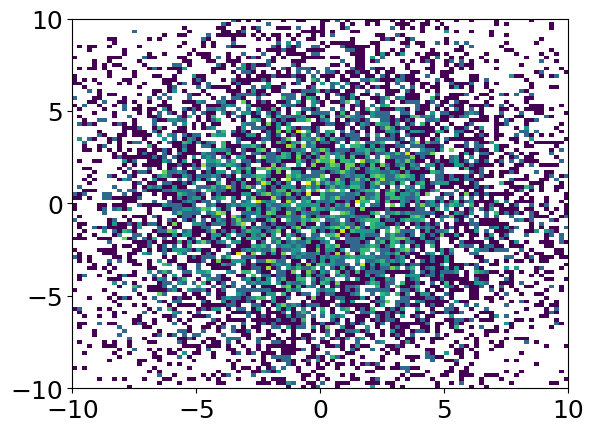

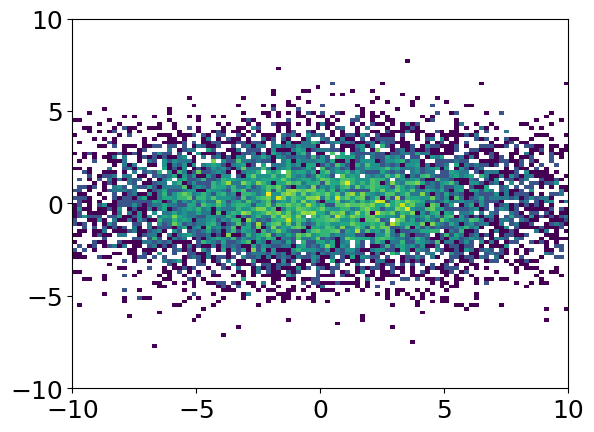

In [9]:
@jax.jit
def Ferrers_density(x, y, z, params):

    '''
    params include: 'logM_bar', 'Rs_bar', 'q_bar', 'p_bar'
    '''
    p, q, Rs = params['p_bar'], params['q_bar'], params['Rs_bar']
    M = 10.0 ** params['logM_bar']
    r = jnp.sqrt(x**2 + (y / p)**2 + (z / q)**2)
    rho = 105 * M / (32 * jnp.pi * p * q * Rs**3) * (1 - (r / Rs)**2)**2
    rho = jnp.where(r <= Rs, rho, 0.0)
    return rho

@jax.jit
def Dehnen_density(x, y, z, params):

    '''
    Dehnen profile: rho = (M / (4π p q Rs^3)) * (r/Rs)^(-n) * (1 + r/Rs)^(n-4), where n = 2
    '''

    p, q, Rs = params['p_bar'], params['q_bar'], params['Rs_bar']
    M = 10.0 ** params['logM_bar']
    r = jnp.sqrt(x**2 + (y / p)**2 + (z / q)**2)

    val = M / (4 * jnp.pi * p * q * Rs**3) * (r / Rs)**(-2) * (1 + r / Rs)**(-2) * jnp.exp(-(z / 3)**4) * jnp.exp(-(r / 10)**4)

    return val

def density_func(x, y, z, params):
    return DoubleExponentialDisk_density(x, y, z, params) + Dehnen_density(x, y, z, params)

def density_func_agama(x):
    return np.array(density_func(x[:, 0], x[:, 1], x[:, 2], params_dict))

params_dict = {
    'rho0_disc': 1e9,
    'Rd_disc': 3.0,
    'hz_disc': 0.3,
    'logM_bar': 10.,
    'Rs_bar': 5.0,
    'q_bar': 0.4,
    'p_bar':0.4,
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0,
}

# bounds = jnp.array(
#     [
#         [-15.0, 15.0],  # x
#         [-15.0, 15.0],  # y
#         [-5.0, 5.0],    # z
#     ],
#     dtype=jnp.float32,
# )

# n_samples = 10_000
# n_x = 60
# n_y = 60
# n_z = 20


# key = jax.random.PRNGKey(0)
# sample_ic_dict = sample_from_density_grid(
#     key,
#     density_func,
#     params_dict,
#     bounds,
#     n_samples=n_samples,
#     n_x=n_x,
#     n_y=n_y,
#     n_z=n_z,
# )
# samples = np.asarray(sample_ic_dict["samples"])
# # dict_data['w0'] = jnp.array(samples)

# plt.hist2d(samples[:, 0], samples[:, 1], bins=100, range=[[-10, 10], [-10, 10]], cmap='viridis', norm='log')
# plt.show()

# plt.hist2d(samples[:, 0], samples[:, 2], bins=100, range=[[-10, 10], [-10, 10]], cmap='viridis', norm='log')
# plt.show()

samples = np.array([
    np.random.normal(0, 5, 10000),
    np.random.normal(0, 5, 10000),
    np.random.normal(0, 2, 10000)
]).T

plt.hist2d(samples[:, 0], samples[:, 1], bins=100, range=[[-10, 10], [-10, 10]], cmap='viridis', norm='log')
plt.show()

plt.hist2d(samples[:, 0], samples[:, 2], bins=100, range=[[-10, 10], [-10, 10]], cmap='viridis', norm='log')
plt.show()

In [10]:
params_halo_pot = {
    'logM': 11.8,
    'Rs': 16.0,
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

w0 = jnp.array(samples)
n_particles = w0.shape[0]
params_disk_rho = params_dict
NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-2, 15.0, 8.
Nphi = 200
N_int = 10_000
dict_phi = get_phi_m(density_func, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

#=========================================== GET INITIAL VELOCITY ===================================================
@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).

    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)

    # --- Step 1: Compute Sigma_z (Vertical Integration) ---

    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)

    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)

    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0

    sigma_z2 = (1.0 / nu_val) * integral_val

    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)

    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)

    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR

    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)

        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)

    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)

    v_phi_total_sq = term1 + term2 + term3

    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R

    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))

    return output


get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
# jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
def get_w0_new(w0, key1, key2, key3, n_particles):
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)
    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R # 2 sigma dispersion
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi
    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)
    return jnp.array([x, y, w0[:,2], vx, vy, vz]).T
key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
w0_new = get_w0_new(w0, key1, key2, key3, n_particles)

## AGAMA results

In [11]:
disc_density_agama = agama.Potential(type = 'Cylspline', density = density_func_agama, symmetry = 'Triaxial', Rmin = 0.1, Rmax = 30, zmin = 0.01, zmax=15)
halo_density_agama = agama.Potential(type = 'NFW', mass = 10**params_halo_pot['logM'], scaleRadius = params_halo_pot['Rs'])
pot_agama = agama.Potential(disc_density_agama , halo_density_agama)

w0_new_agama = np.array(w0_new)
w0_new_agama[:, 3:] = w0_new_agama[:, 3:] * 1.0227121650530867  # convert from kpc/Gyr to km/s
result_agama = agama.orbit(potential=pot_agama, ic=w0_new_agama, time=5, trajsize = 2000, Omega = -34)

10000 orbits complete (382 orbits/s)                    


100%|██████████| 10000/10000 [00:00<00:00, 470809.88it/s]


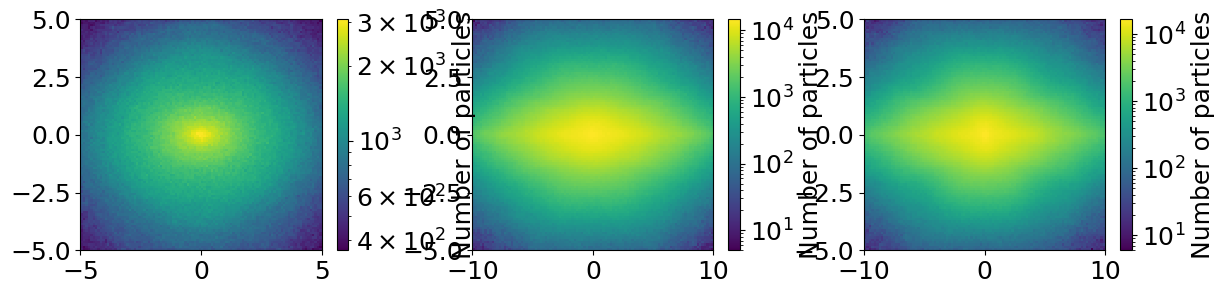

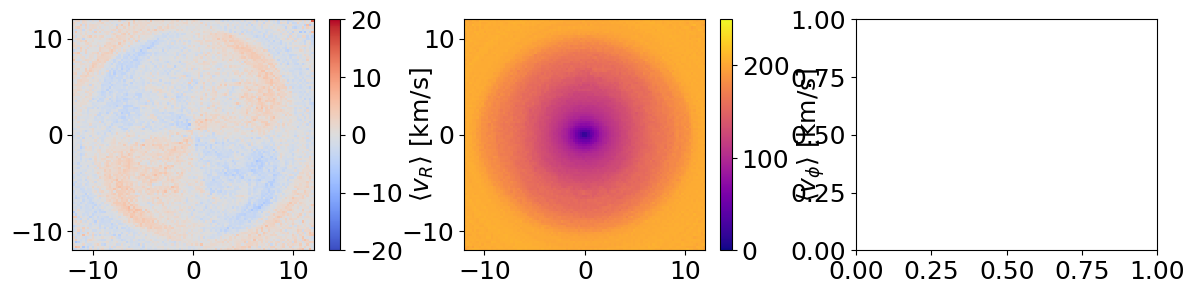

In [12]:
from tqdm import tqdm

def getCylindricalFromCartesian_clockwise(x, y, vx, vy):
    R = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    vR = (x*vx + y*vy) / R
    vphi = -(x*vy - y*vx) / R
    return R, phi, vR, vphi

x_agama, y_agama, z_agama = [], [], []
vx_agama, vy_agama, vz_agama = [], [], []
for i, (times, trj) in tqdm(enumerate(result_agama), total = len(result_agama)):
    x_agama.append(trj[:,0])
    y_agama.append(trj[:,1])
    z_agama.append(trj[:,2])
    vx_agama.append(trj[:,3])
    vy_agama.append(trj[:,4])
    vz_agama.append(trj[:,5])

x_agama = np.array(x_agama).flatten()
y_agama = np.array(y_agama).flatten()
z_agama = np.array(z_agama).flatten()
vx_agama = np.array(vx_agama).flatten()
vy_agama = np.array(vy_agama).flatten()
vz_agama = np.array(vz_agama).flatten()

R_agama, phi_agama, vR_agama, vphi_agama = getCylindricalFromCartesian_clockwise(x_agama, y_agama, vx_agama, vy_agama)

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
_, _, _, cb = ax[0].hist2d(x_agama, y_agama, bins=100, range=[[-5, 5], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0], label='Number of particles')
_, _, _, cb = ax[1].hist2d(x_agama, z_agama, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1], label='Number of particles')
_, _, _, cb = ax[2].hist2d(y_agama, z_agama, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2], label='Number of particles')
plt.show()


fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=100, range=[[-12, 12], [-12, 12]])
H_vR = np.histogram2d(x_agama, y_agama, bins=100, range=[[-12, 12], [-12, 12]], weights=vR_agama)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_vR.T, cmap='coolwarm', vmin = -20, vmax = 20)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_R \rangle$ [km/s]')
H_vphi = np.histogram2d(x_agama, y_agama, bins=100, range=[[-12, 12], [-12, 12]], weights=vphi_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_vphi.T, cmap='plasma', vmin = 0, vmax = 250)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_\phi \rangle$ [km/s]')

In [14]:
KPCGYR_TO_KMS

np.float64(0.9777922216807892)

## Our leapfrog integrator results

In [24]:
def _split(w):
    return w[:3], w[3:]

def _merge(r, v):
    return jnp.concatenate([r, v], axis=0)

@partial(jax.jit, static_argnames=('acc_fn', 'n_steps', 'unroll',))
def integrate_leapfrog_barred_traj(w0, acc_fn, n_steps, dt = 0.010, t0 = 0.0, Omega = 0.0, unroll=True):
    """Leapfrog (KDK) — returns final time and final state only.

    num_segments_Rzphi: int
        Number of segments for Rzphi bin counting. MUST equal to nRzphi.prod()
    num_segments_XY: int
        Number of segments for XY bin counting. MUST equal to nXY.prod()
    
    v0 and s are arrays of reference velocity and dispersion for each XY cell for the GH coefficent calculation. Length should equal to nXY.prod()
    """

    def step(carry, _):
        t, y = carry
        r, v = _split(y)

        # Gravity half-kick
        a0 = acc_fn(*r)
        v_half = v + 0.5 * dt * a0

        # Exact Omega-subflow for:
        #   xdot = vx + Omega*y, ydot = vy - Omega*x
        #   vxdot = Omega*vy,     vydot = -Omega*vx
        theta = Omega * dt
        c, s_theta = jnp.cos(theta), jnp.sin(theta)

        x_bar = r[0] + dt * v_half[0]
        y_bar = r[1] + dt * v_half[1]
        x_new = c * x_bar + s_theta * y_bar
        y_new = -s_theta * x_bar + c * y_bar
        z_new = r[2] + dt * v_half[2]

        vx_rot = c * v_half[0] + s_theta * v_half[1]
        vy_rot = -s_theta * v_half[0] + c * v_half[1]
        vz_rot = v_half[2]

        r_new = jnp.array([x_new, y_new, z_new])
        v_rot = jnp.array([vx_rot, vy_rot, vz_rot])
        t_new = t + dt

        # Gravity half-kick at updated position
        a1 = acc_fn(*r_new)
        v_new = v_rot + 0.5 * dt * a1
        y_new = _merge(r_new, v_new)
        return (t_new, y_new), (t_new, y_new)

    (_, _), (tN, wN) = jax.lax.scan(step, (t0, w0), xs=None, length=n_steps, unroll=unroll)

    return tN, wN 

def _deriv_barred(state, acc_fn, Omega):
    """RHS of the co-rotating frame ODE.

    State = [x, y, z, vx, vy, vz] where velocities are inertial
    components rotated into bar-frame axes.

    ODE:  dx/dt  = vx + Omega*y      dvx/dt = ax + Omega*vy
          dy/dt  = vy - Omega*x      dvy/dt = ay - Omega*vx
          dz/dt  = vz                dvz/dt = az
    """
    x, y_pos, z, vx, vy, vz = state[0], state[1], state[2], state[3], state[4], state[5]
    ax, ay, az = acc_fn(x, y_pos, z)
    return jnp.array([
        vx + Omega * y_pos,
        vy - Omega * x,
        vz,
        ax + Omega * vy,
        ay - Omega * vx,
        az,
    ])

@partial(jax.jit, static_argnames=('acc_fn', 'N_max'))
def integrate_adaptive_barred_traj(
    w0, acc_fn, N_max, T_total,
    dt_init=0.010, Omega=0.0,
    atol=1e-8, rtol=1e-6,
    dt_min=1e-5, dt_max=0.1,
):
    """Bogacki-Shampine RK2(3) integrator with embedded error control.

    Uses 3 acc_fn calls per step (FSAL). No pot_fn calls during integration.
    Step size controlled by local truncation error, not energy conservation.
    E_J checked only at orbit level for validity.

    Parameters
    ----------
    w0 : array (6,)
        Initial phase-space state [x, y, z, vx, vy, vz] in bar frame.
    acc_fn : callable
        Acceleration function acc_fn(x, y, z) -> (ax, ay, az) in bar frame.
    pot_fn : callable
        Potential function pot_fn(x, y, z) -> Phi (only for orbit-level E_J check).
    N_max : int
        Maximum number of scan iterations (static for jit).
    T_total : float
        Total integration time.
    dt_init : float
        Initial step size.
    Omega : float
        Bar pattern speed.
    atol : float
        Absolute error tolerance (per component).
    rtol : float
        Relative error tolerance (per component).
    dt_min, dt_max : float
        Step size bounds.

    Returns
    -------
    8-tuple: (Rzphi_bin_counts, surface_density, h1, h2, h3, h4, valid, n_accepted)
    """
    # Compute initial derivative (FSAL: reused as k1 in first step)
    k1_init = _deriv_barred(w0, acc_fn, Omega)

    # BS23 error coefficients: err = y3 - y2
    # err = dt * (-5/72*k1 + 1/12*k2 + 1/9*k3 - 1/8*k4)
    e1, e2, e3, e4 = -5.0/72.0, 1.0/12.0, 1.0/9.0, -1.0/8.0

    safety = 0.9

    def scan_body(carry, _):
        t, y, dt, k1 = carry

        # No early stopping — all N_max iterations do useful work.
        # Orbits past T_total keep integrating; extra points improve
        # the time-averaged density/kinematics at no extra cost.

        # ── Bogacki-Shampine RK2(3) stages ──
        # k1 is carried from previous step (FSAL)
        k2 = _deriv_barred(y + 0.5 * dt * k1, acc_fn, Omega)          # stage 2
        k3 = _deriv_barred(y + 0.75 * dt * k2, acc_fn, Omega)         # stage 3
        y_new = y + dt * (2.0/9.0 * k1 + 1.0/3.0 * k2 + 4.0/9.0 * k3)  # 3rd order
        k4 = _deriv_barred(y_new, acc_fn, Omega)                       # stage 4 (FSAL)

        # ── Embedded error estimate ──
        err_vec = dt * (e1 * k1 + e2 * k2 + e3 * k3 + e4 * k4)

        # Per-component scaling (AGAMA-style)
        scale = atol + rtol * jnp.maximum(jnp.fabs(y), jnp.fabs(y_new))
        err_scaled = err_vec / scale
        err_norm = jnp.sqrt(jnp.mean(err_scaled**2))  # RMS norm

        # Accept if err_norm <= 1
        accept = err_norm <= 1.0

        # Update state
        y_out = jnp.where(accept, y_new, y)
        t_new = jnp.where(accept, t + dt, t)
        # FSAL: if accepted, next k1 = k4; if rejected, keep old k1
        k1_new = jnp.where(accept, k4, k1)

        # Step size adjustment: dt_new = dt * safety * err^(-1/3) for 3rd order method
        scale_factor = safety * jnp.power(jnp.maximum(err_norm, 1e-10), -1.0/3.0)
        scale_factor = jnp.clip(scale_factor, 0.2, 5.0)
        dt_new = dt * scale_factor
        dt_new = jnp.clip(dt_new, dt_min, dt_max)

        valid_flag = accept.astype(jnp.float32)
        # Output dt_used for time-weighting (0 if rejected)
        dt_out = jnp.where(accept, dt, 0.0)

        return (t_new, y_out, dt_new, k1_new), (y_out, valid_flag, dt_out)

    init_carry = (0.0, w0, dt_init, k1_init)
    (t_final, y_final, dt_final, _), (y_traj, valid_mask, dt_traj) = jax.lax.scan(
        scan_body, init_carry, xs=None, length=N_max
    )
    return dt_traj, y_traj


_R = jnp.sqrt(w0_new[:,0]**2 + w0_new[:,1]**2)
_z = w0_new[:,2]

T_orb = jax.vmap(estimate_orbital_timescale, in_axes=(0, None, None, 0))(
    _R,
    potential_func,
    (dict_phi, params_halo_pot),
    _z
)

N_step_per_orb = 250
N_dynamical_time = 8
dt = T_orb / N_step_per_orb
time_integrate = T_orb * N_dynamical_time
N_steps = N_step_per_orb * N_dynamical_time
#=========================================== Integrate orbits =======================================================
@jax.jit
def acc_fn(x, y, z):
    a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
    a_disk = get_acc(x, y, z, dict_phi)
    return a_halo + a_disk

import time
time_start = time.time()
_integrate_vmap = jax.vmap(integrate_leapfrog_barred_traj, 
                        in_axes=(0, None, None, 0, None, None, None))
_integrate_adaptive_vmap = jax.vmap(integrate_adaptive_barred_traj,
                        in_axes=(0, None, None, None, None, None, None, None, None, None))
# tN, wN = _integrate_vmap(w0_new, acc_fn, N_steps, dt, 0.0, -34.0 / KPCGYR_TO_KMS , False)

N_max = 4_000
T_total_per_orbit = T_orb * N_dynamical_time
dt_init_adaptive = T_orb / N_step_per_orb
dt_traj, wN = _integrate_adaptive_vmap(
    w0_new, acc_fn, N_max, T_total_per_orbit,
    dt_init_adaptive, -34.0 / KPCGYR_TO_KMS, 1e-8, 1e-6, 1e-5, 0.5)
dt_traj.block_until_ready()
time_end = time.time()
print(f"Time taken to integrate orbits: {time_end - time_start:.2f} seconds")
x_lf, y_lf, z_lf = wN[:,:,0].flatten(), wN[:,:,1].flatten(), wN[:,:,2].flatten()
vx_lf, vy_lf, vz_lf = wN[:,:,3].flatten() * KPCGYR_TO_KMS, wN[:,:,4].flatten() * KPCGYR_TO_KMS, wN[:,:,5].flatten() * KPCGYR_TO_KMS
print("Leapfrog integration done.")

R_lf, phi_lf, vR_lf, vphi_lf = getCylindricalFromCartesian_clockwise(x_lf, y_lf, vx_lf, vy_lf)

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
_, _, _, cb = ax[0].hist2d(x_lf, y_lf, bins=100, range=[[-5, 5], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0], label='Number of particles')
_, _, _, cb = ax[1].hist2d(x_lf, z_lf, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1], label='Number of particles')
_, _, _, cb = ax[2].hist2d(y_lf, z_lf, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2], label='Number of particles')
plt.show()


fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=75, range=[[-10, 10], [-10, 10]])
H_vR = np.histogram2d(x_lf, y_lf, bins=75, range=[[-10, 10], [-10, 10]], weights=vR_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_vR.T, cmap='coolwarm', vmin = -30, vmax = 30)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_R \rangle$ [km/s]')
H_vphi = np.histogram2d(x_lf, y_lf, bins=75, range=[[-10, 10], [-10, 10]], weights=vphi_lf)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_vphi.T, cmap='plasma', vmin = 0, vmax = 250)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_\phi \rangle$ [km/s]')


TypeError: mul got incompatible shapes for broadcasting: (10000,), (6,).

# Residual

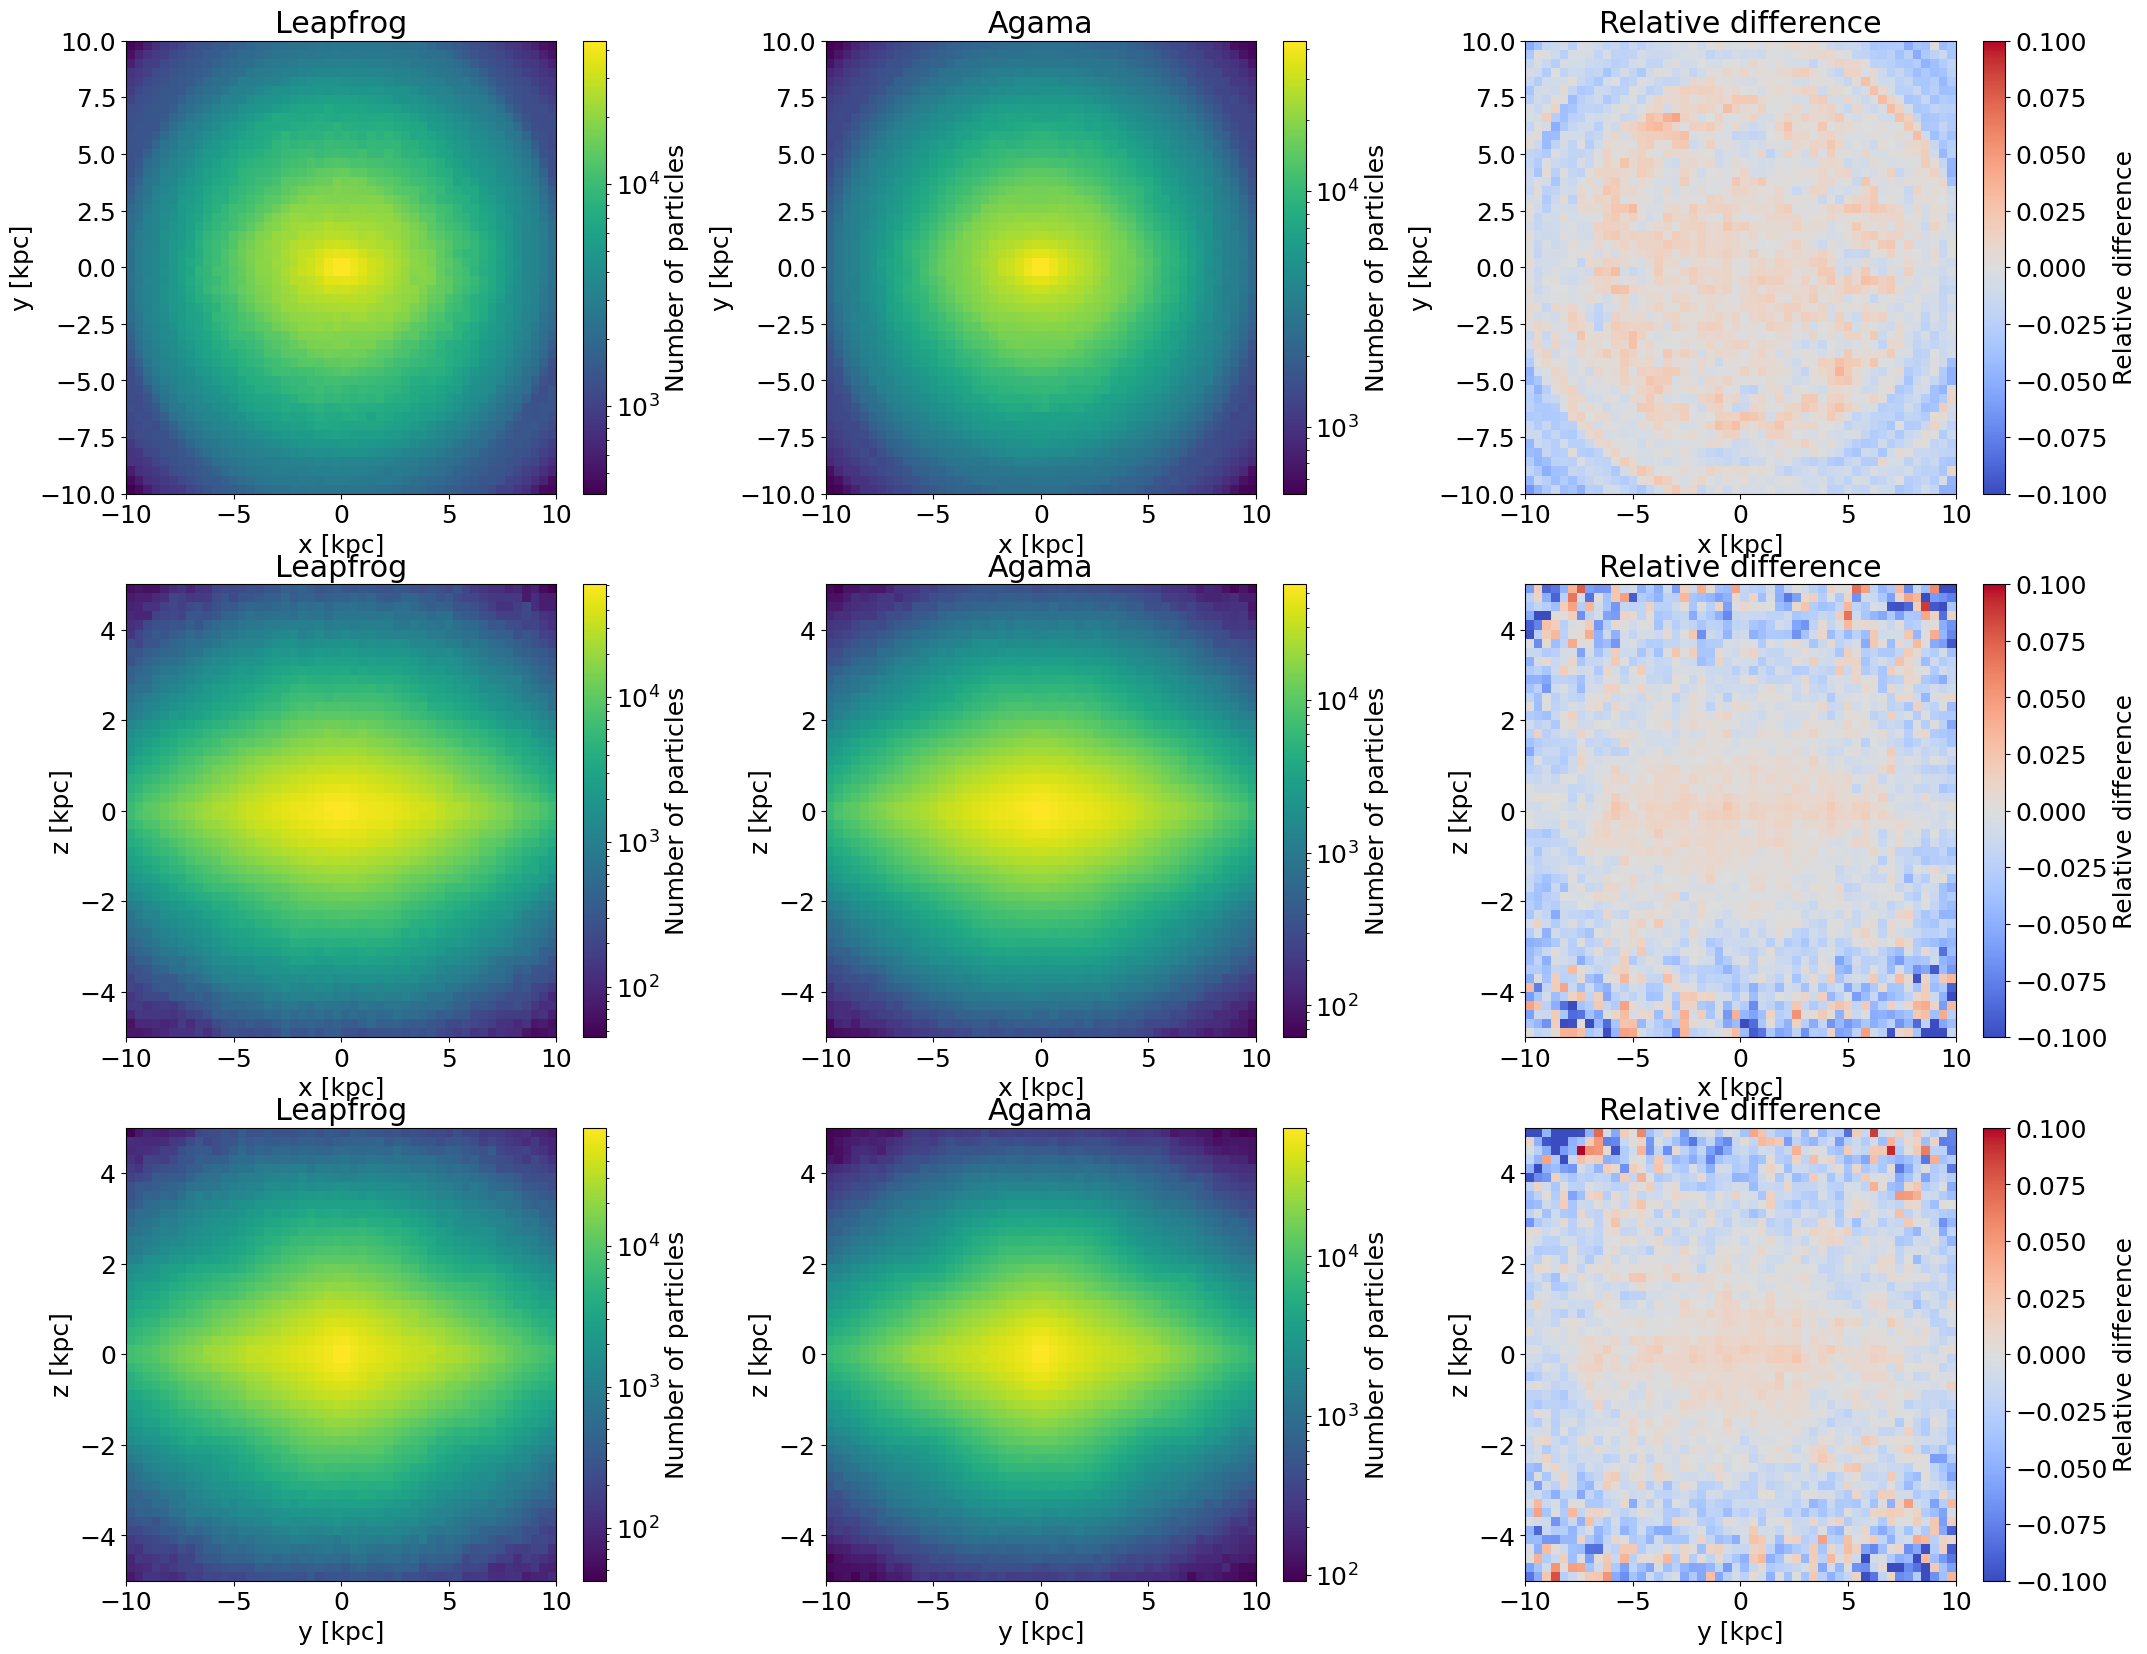

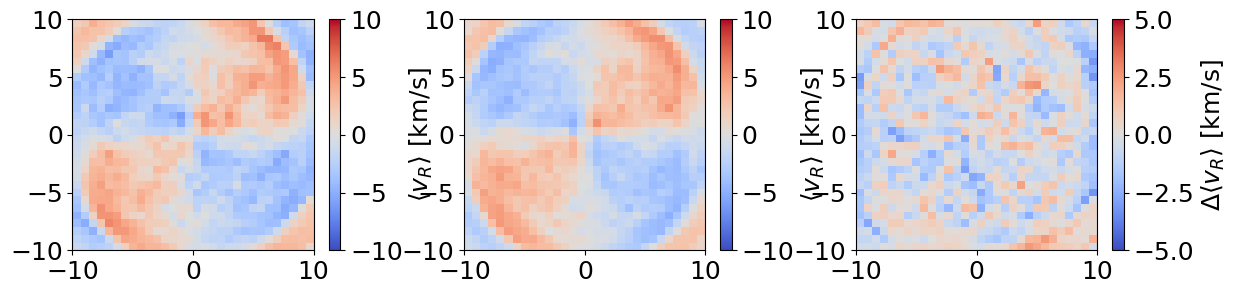

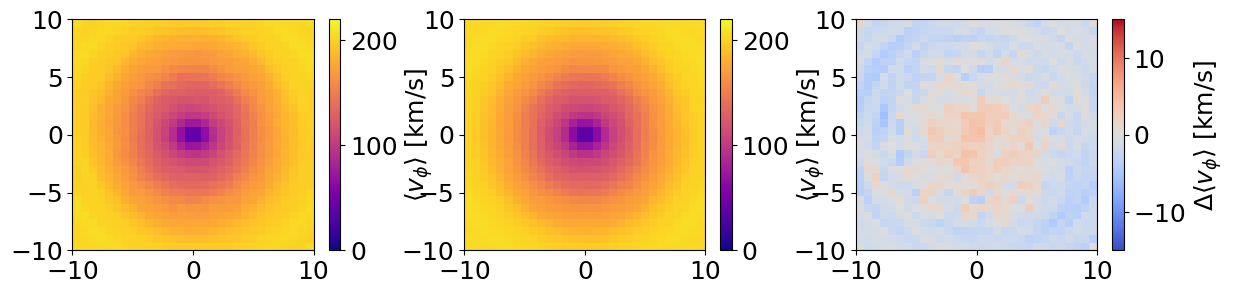

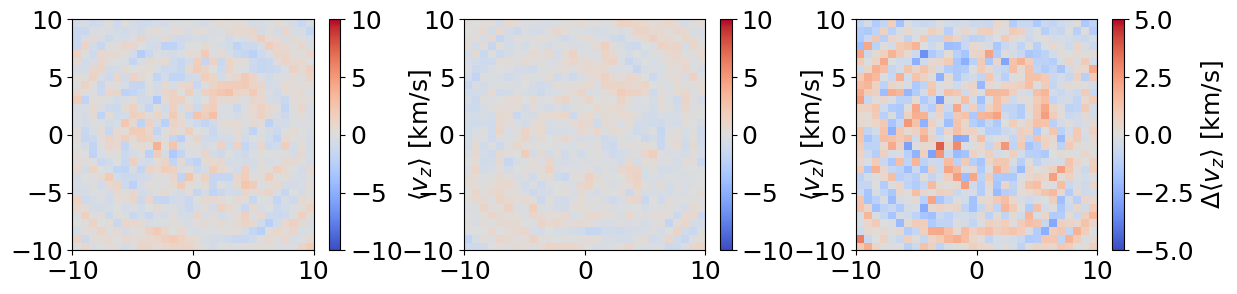

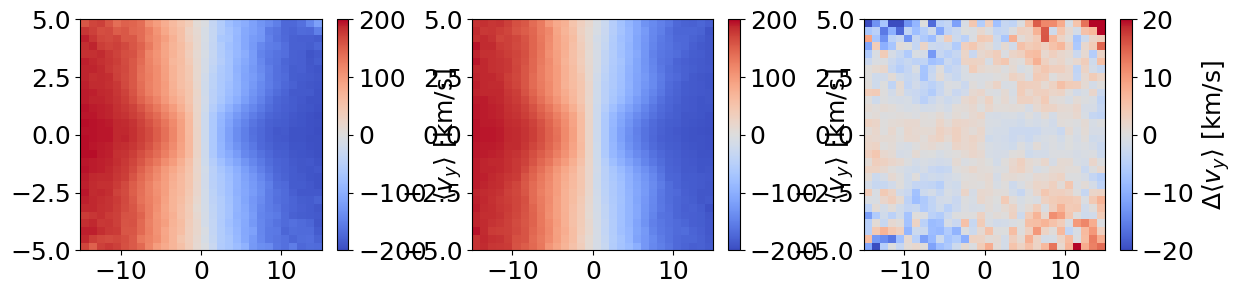

In [25]:
fig, ax = plt.subplots(3,3, figsize=(25,20), gridspec_kw={'wspace':0.3})
H_lf, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=50, range=[[-10, 10], [-10, 10]])
cb = ax[0][0].pcolormesh(xedge, yedge, H_lf.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0][0], label='Number of particles')
ax[0][0].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Leapfrog')
H_agama, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=50, range=[[-10, 10], [-10, 10]])
cb = ax[0][1].pcolormesh(xedge, yedge, H_agama.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0][1], label='Number of particles')
ax[0][1].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Agama')
cb = ax[0][2].pcolormesh(xedge, yedge, ((H_lf - H_agama) / (H_lf + H_agama)/2 + 1e-10).T, cmap='coolwarm', vmax = 0.1, vmin = -0.1)
plt.colorbar(cb, ax=ax[0][2], label='Relative difference')
ax[0][2].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Relative difference')

H_lf, xedge, yedge = np.histogram2d(x_lf, z_lf, bins=50, range=[[-10, 10], [-5, 5]])
cb = ax[1][0].pcolormesh(xedge, yedge, H_lf.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1][0], label='Number of particles')
ax[1][0].set(xlabel='x [kpc]', ylabel='z [kpc]', title='Leapfrog')
H_agama, xedge, yedge = np.histogram2d(x_agama, z_agama, bins=50, range=[[-10, 10], [-5, 5]])
cb = ax[1][1].pcolormesh(xedge, yedge, H_agama.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1][1], label='Number of particles')
ax[1][1].set(xlabel='x [kpc]', ylabel='z [kpc]', title='Agama')
cb = ax[1][2].pcolormesh(xedge, yedge, ((H_lf - H_agama) / (H_lf + H_agama)/2 + 1e-10).T, cmap='coolwarm', vmax = 0.1, vmin = -0.1)
plt.colorbar(cb, ax=ax[1][2], label='Relative difference')
ax[1][2].set(xlabel='x [kpc]', ylabel='z [kpc]', title='Relative difference')

H_lf, xedge, yedge = np.histogram2d(y_lf, z_lf, bins=50, range=[[-10, 10], [-5, 5]])
cb = ax[2][0].pcolormesh(xedge, yedge, H_lf.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2][0], label='Number of particles')
ax[2][0].set(xlabel='y [kpc]', ylabel='z [kpc]', title='Leapfrog')
H_agama, xedge, yedge = np.histogram2d(y_agama, z_agama, bins=50, range=[[-10, 10], [-5, 5]])
cb = ax[2][1].pcolormesh(xedge, yedge, H_agama.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2][1], label='Number of particles')
ax[2][1].set(xlabel='y [kpc]', ylabel='z [kpc]', title='Agama')
cb = ax[2][2].pcolormesh(xedge, yedge, ((H_lf - H_agama) / (H_lf + H_agama)/2 + 1e-10).T, cmap='coolwarm', vmax = 0.1, vmin = -0.1)
plt.colorbar(cb, ax=ax[2][2], label='Relative difference')
ax[2][2].set(xlabel='y [kpc]', ylabel='z [kpc]', title='Relative difference')
plt.show()



fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]])
H_vR_lf = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]], weights=vR_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_vR_lf.T, cmap='coolwarm', vmin = -10, vmax = 10)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_R \rangle$ [km/s]')

H_xy, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]])
H_vR_agama = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]], weights=vR_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_vR_agama.T, cmap='coolwarm', vmin = -10, vmax = 10)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_R \rangle$ [km/s]')

cb = ax[2].pcolormesh(xedge, yedge, (H_vR_lf - H_vR_agama).T, cmap='coolwarm', vmin = -5, vmax = 5)
plt.colorbar(cb, ax=ax[2], label=r'$\Delta \langle v_R \rangle$ [km/s]')
plt.show()

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]])
H_vphi_lf = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]], weights=vphi_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_vphi_lf.T, cmap='plasma', vmin = 0, vmax = 220)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_\phi \rangle$ [km/s]')

H_xy, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]])
H_vphi_agama = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]], weights=vphi_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_vphi_agama.T, cmap='plasma', vmin = 0, vmax = 220)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_\phi \rangle$ [km/s]')

cb = ax[2].pcolormesh(xedge, yedge, (H_vphi_lf - H_vphi_agama).T, cmap='coolwarm', vmin = -15, vmax = 15)
plt.colorbar(cb, ax=ax[2], label=r'$\Delta \langle v_\phi \rangle$ [km/s]')
plt.show()

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]])
H_z_lf = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]], weights=vz_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_z_lf.T, cmap='coolwarm', vmin = -10, vmax = 10)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_z \rangle$ [km/s]')

H_xy, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]])
H_z_agama = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]], weights=vz_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_z_agama.T, cmap='coolwarm', vmin = -10, vmax = 10)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_z \rangle$ [km/s]')

cb = ax[2].pcolormesh(xedge, yedge, (H_z_lf - H_z_agama).T, cmap='coolwarm', vmin = -5, vmax = 5)
plt.colorbar(cb, ax=ax[2], label=r'$\Delta \langle v_z \rangle$ [km/s]')
plt.show()


fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, z_lf, bins=30, range=[[-15, 15], [-5, 5]])
H_z_lf = np.histogram2d(x_lf, z_lf, bins=30, range=[[-15, 15], [-5, 5]], weights=vy_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_z_lf.T, cmap='coolwarm', vmin = -200, vmax = 200)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_y \rangle$ [km/s]')

H_xy, xedge, yedge = np.histogram2d(x_agama, z_agama, bins=30, range=[[-15, 15], [-5, 5]])
H_z_agama = np.histogram2d(x_agama, z_agama, bins=30, range=[[-15, 15], [-5, 5]], weights=vy_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_z_agama.T, cmap='coolwarm', vmin = -200, vmax = 200)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_y \rangle$ [km/s]')

cb = ax[2].pcolormesh(xedge, yedge, (H_z_lf - H_z_agama).T, cmap='coolwarm', vmin = -20, vmax = 20)
plt.colorbar(cb, ax=ax[2], label=r'$\Delta \langle v_y \rangle$ [km/s]')
plt.show()

# Adaptive stepsize integrator

Time taken to integrate orbits: 23.58 seconds
Leapfrog integration done.


100%|██████████| 10000/10000 [00:13<00:00, 725.57it/s]


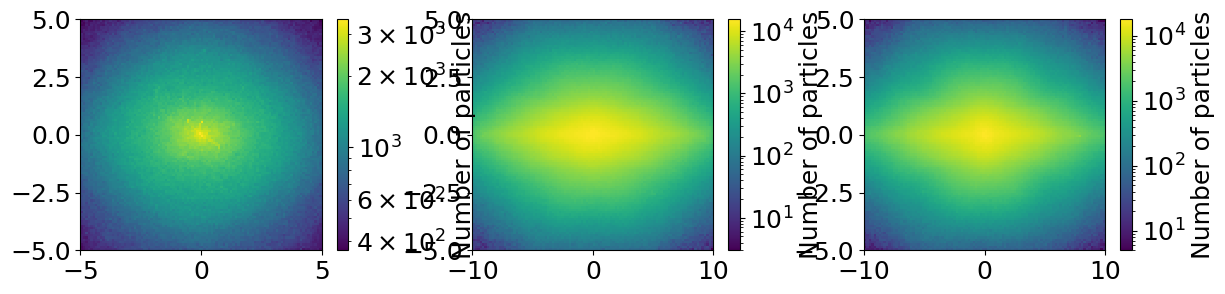

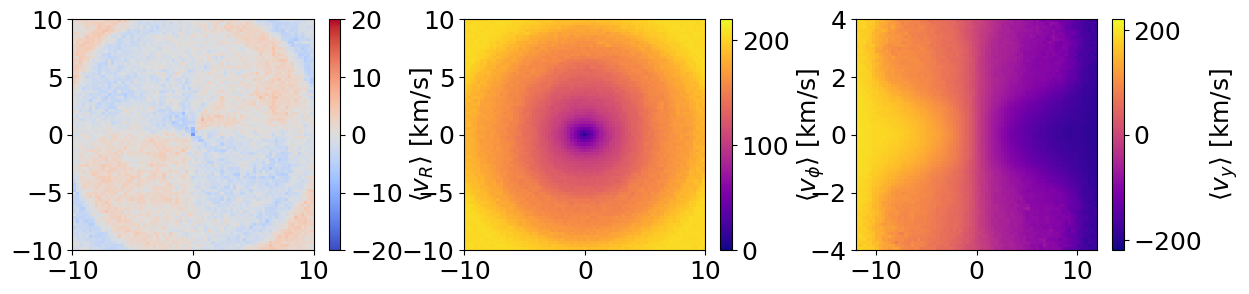

In [21]:
def _split(w):
    return w[:3], w[3:]

def _merge(r, v):
    return jnp.concatenate([r, v], axis=0)

def _deriv_barred(state, acc_fn, Omega):
    """RHS of the co-rotating frame ODE.

    State = [x, y, z, vx, vy, vz] where velocities are inertial
    components rotated into bar-frame axes.

    ODE:  dx/dt  = vx + Omega*y      dvx/dt = ax + Omega*vy
          dy/dt  = vy - Omega*x      dvy/dt = ay - Omega*vx
          dz/dt  = vz                dvz/dt = az
    """
    x, y_pos, z, vx, vy, vz = state[0], state[1], state[2], state[3], state[4], state[5]
    ax, ay, az = acc_fn(x, y_pos, z)
    return jnp.array([
        vx + Omega * y_pos,
        vy - Omega * x,
        vz,
        ax + Omega * vy,
        ay - Omega * vx,
        az,
    ])

@partial(jax.jit, static_argnames=('acc_fn', 'N_max'))
def integrate_adaptive_barred_traj(
    w0, acc_fn, N_max, T_total,
    dt_init=0.010, Omega=0.0,
    atol=1e-8, rtol=1e-6,
    dt_min=1e-5, dt_max=0.1,
):
    """Bogacki-Shampine RK2(3) integrator with embedded error control.

    Uses 3 acc_fn calls per step (FSAL). No pot_fn calls during integration.
    Step size controlled by local truncation error, not energy conservation.
    E_J checked only at orbit level for validity.

    Parameters
    ----------
    w0 : array (6,)
        Initial phase-space state [x, y, z, vx, vy, vz] in bar frame.
    acc_fn : callable
        Acceleration function acc_fn(x, y, z) -> (ax, ay, az) in bar frame.
    pot_fn : callable
        Potential function pot_fn(x, y, z) -> Phi (only for orbit-level E_J check).
    N_max : int
        Maximum number of scan iterations (static for jit).
    T_total : float
        Total integration time.
    dt_init : float
        Initial step size.
    Omega : float
        Bar pattern speed.
    atol : float
        Absolute error tolerance (per component).
    rtol : float
        Relative error tolerance (per component).
    dt_min, dt_max : float
        Step size bounds.

    Returns
    -------
    8-tuple: (Rzphi_bin_counts, surface_density, h1, h2, h3, h4, valid, n_accepted)
    """
    # Compute initial derivative (FSAL: reused as k1 in first step)
    k1_init = _deriv_barred(w0, acc_fn, Omega)

    # BS23 error coefficients: err = y3 - y2
    # err = dt * (-5/72*k1 + 1/12*k2 + 1/9*k3 - 1/8*k4)
    e1, e2, e3, e4 = -5.0/72.0, 1.0/12.0, 1.0/9.0, -1.0/8.0

    safety = 0.9

    def scan_body(carry, _):
        t, y, dt, k1 = carry

        # No early stopping — all N_max iterations do useful work.
        # Orbits past T_total keep integrating; extra points improve
        # the time-averaged density/kinematics at no extra cost.

        # ── Bogacki-Shampine RK2(3) stages ──
        # k1 is carried from previous step (FSAL)
        k2 = _deriv_barred(y + 0.5 * dt * k1, acc_fn, Omega)          # stage 2
        k3 = _deriv_barred(y + 0.75 * dt * k2, acc_fn, Omega)         # stage 3
        y_new = y + dt * (2.0/9.0 * k1 + 1.0/3.0 * k2 + 4.0/9.0 * k3)  # 3rd order
        k4 = _deriv_barred(y_new, acc_fn, Omega)                       # stage 4 (FSAL)

        # ── Embedded error estimate ──
        err_vec = dt * (e1 * k1 + e2 * k2 + e3 * k3 + e4 * k4)

        # Per-component scaling (AGAMA-style)
        scale = atol + rtol * jnp.maximum(jnp.fabs(y), jnp.fabs(y_new))
        err_scaled = err_vec / scale
        err_norm = jnp.sqrt(jnp.mean(err_scaled**2))  # RMS norm

        # Accept if err_norm <= 1
        accept = err_norm <= 1.0

        # Update state
        y_out = jnp.where(accept, y_new, y)
        t_new = jnp.where(accept, t + dt, t)
        # FSAL: if accepted, next k1 = k4; if rejected, keep old k1
        k1_new = jnp.where(accept, k4, k1)

        # Step size adjustment: dt_new = dt * safety * err^(-1/3) for 3rd order method
        scale_factor = safety * jnp.power(jnp.maximum(err_norm, 1e-10), -1.0/3.0)
        scale_factor = jnp.clip(scale_factor, 0.2, 5.0)
        dt_new = dt * scale_factor
        dt_new = jnp.clip(dt_new, dt_min, dt_max)

        valid_flag = accept.astype(jnp.float32)
        # Output dt_used for time-weighting (0 if rejected)
        dt_out = jnp.where(accept, dt, 0.0)

        return (t_new, y_out, dt_new, k1_new), (y_out, valid_flag, dt_out)

    init_carry = (0.0, w0, dt_init, k1_init)
    (t_final, y_final, dt_final, _), (y_traj, valid_mask, dt_traj) = jax.lax.scan(
        scan_body, init_carry, xs=None, length=N_max
    )
    return dt_traj, y_traj


_R = jnp.sqrt(w0_new[:,0]**2 + w0_new[:,1]**2)
_z = w0_new[:,2]

T_orb = jax.vmap(estimate_orbital_timescale, in_axes=(0, None, None, 0))(
    _R,
    potential_func,
    (dict_phi, params_halo_pot),
    _z
)

N_step_per_orb = 100
N_dynamical_time = 40
dt = T_orb / N_step_per_orb
time_integrate = T_orb * N_dynamical_time
N_steps = N_step_per_orb * N_dynamical_time
#=========================================== Integrate orbits =======================================================
@jax.jit
def acc_fn(x, y, z):
    a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
    a_disk = get_acc(x, y, z, dict_phi)
    return a_halo + a_disk

import time
time_start = time.time()
_integrate_adaptive_vmap = jax.vmap(integrate_adaptive_barred_traj,
                        in_axes=(0, None, None, 0, 0, None, None, None, None, None))
# tN, wN = _integrate_vmap(w0_new, acc_fn, N_steps, dt, 0.0, -34.0 / KPCGYR_TO_KMS , False)

N_max = 5_000
T_total_per_orbit = T_orb * N_dynamical_time
dt_init_adaptive = T_orb / N_step_per_orb
dt_traj, wN = _integrate_adaptive_vmap(
    w0_new, acc_fn, N_max, T_total_per_orbit,
    dt_init_adaptive, -34.0 / KPCGYR_TO_KMS, 1e-8, 1e-4, 1e-5, 0.5)
dt_traj.block_until_ready()
time_end = time.time()
_t_traj = jnp.cumsum(dt_traj, axis=1)
print(f"Time taken to integrate orbits: {time_end - time_start:.2f} seconds")
print("Leapfrog integration done.")

x_lf, y_lf, z_lf, vx_lf, vy_lf, vz_lf = [], [], [], [], [], []
for i in tqdm(range(wN.shape[0])):
    t_interp = np.linspace(0, _t_traj[i, -1], 2000)
    x_interp = np.interp(t_interp, _t_traj[i], wN[i,:,0])
    y_interp = np.interp(t_interp, _t_traj[i], wN[i,:,1])
    z_interp = np.interp(t_interp, _t_traj[i], wN[i,:,2])
    vx_interp = np.interp(t_interp, _t_traj[i], wN[i,:,3] * KPCGYR_TO_KMS)
    vy_interp = np.interp(t_interp, _t_traj[i], wN[i,:,4] * KPCGYR_TO_KMS)
    vz_interp = np.interp(t_interp, _t_traj[i], wN[i,:,5] * KPCGYR_TO_KMS)
    x_lf.extend(x_interp)
    y_lf.extend(y_interp)
    z_lf.extend(z_interp)
    vx_lf.extend(vx_interp)
    vy_lf.extend(vy_interp)
    vz_lf.extend(vz_interp)
x_lf, y_lf, z_lf = np.array(x_lf), np.array(y_lf), np.array(z_lf)
vx_lf, vy_lf, vz_lf = np.array(vx_lf), np.array(vy_lf), np.array(vz_lf)

R_lf, phi_lf, vR_lf, vphi_lf = getCylindricalFromCartesian_clockwise(x_lf, y_lf, vx_lf, vy_lf)

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
_, _, _, cb = ax[0].hist2d(x_lf, y_lf, bins=100, range=[[-5, 5], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0], label='Number of particles')
_, _, _, cb = ax[1].hist2d(x_lf, z_lf, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1], label='Number of particles')
_, _, _, cb = ax[2].hist2d(y_lf, z_lf, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2], label='Number of particles')
plt.show()


fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=75, range=[[-10, 10], [-10, 10]])
H_vR = np.histogram2d(x_lf, y_lf, bins=75, range=[[-10, 10], [-10, 10]], weights=vR_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_vR.T, cmap='coolwarm', vmin = -20, vmax = 20)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_R \rangle$ [km/s]')
H_vphi = np.histogram2d(x_lf, y_lf, bins=75, range=[[-10, 10], [-10, 10]], weights=vphi_lf)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_vphi.T, cmap='plasma', vmin = 0, vmax = 220)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_\phi \rangle$ [km/s]')
H_xz, xedge, yedge = np.histogram2d(x_lf, z_lf, bins=75, range=[[-12, 12], [-4, 4]])
H_y = np.histogram2d(x_lf, z_lf, bins=75, range=[[-12, 12], [-4, 4]], weights=vy_lf)[0] / H_xz
cb = ax[2].pcolormesh(xedge, yedge, H_y.T, cmap='plasma', vmin = -220, vmax = 220)
plt.colorbar(cb, ax=ax[2], label=r'$\langle v_y \rangle$ [km/s]')

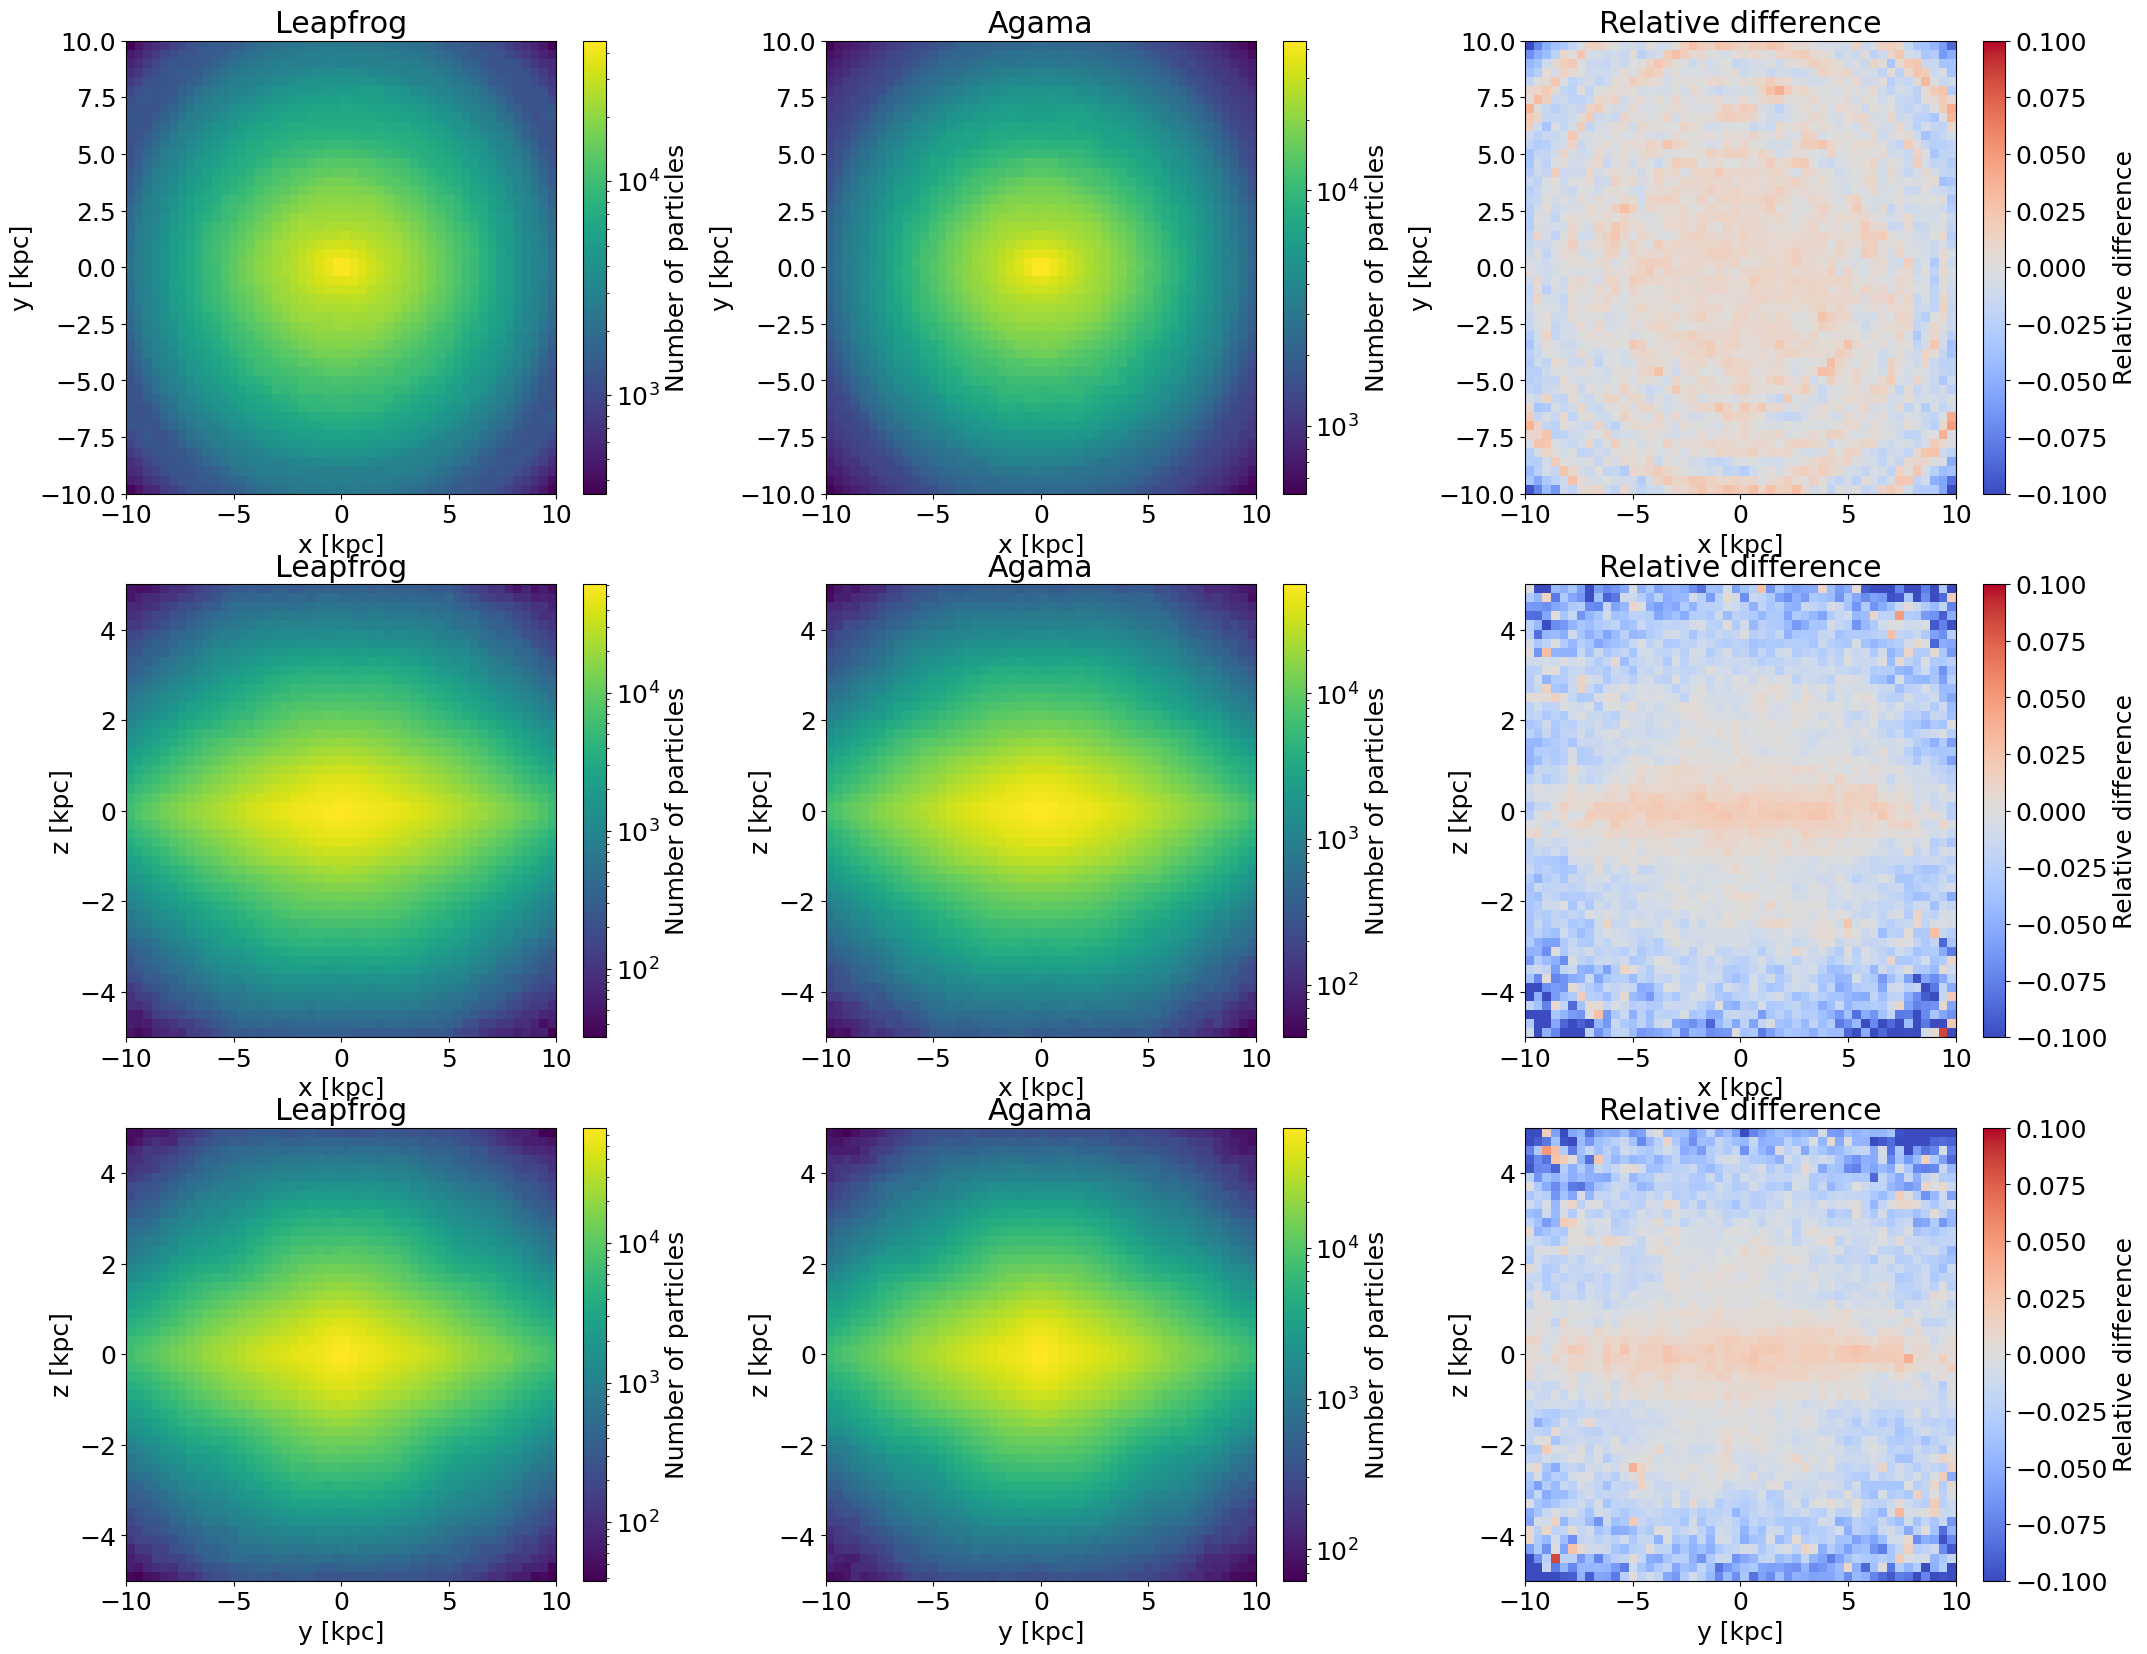

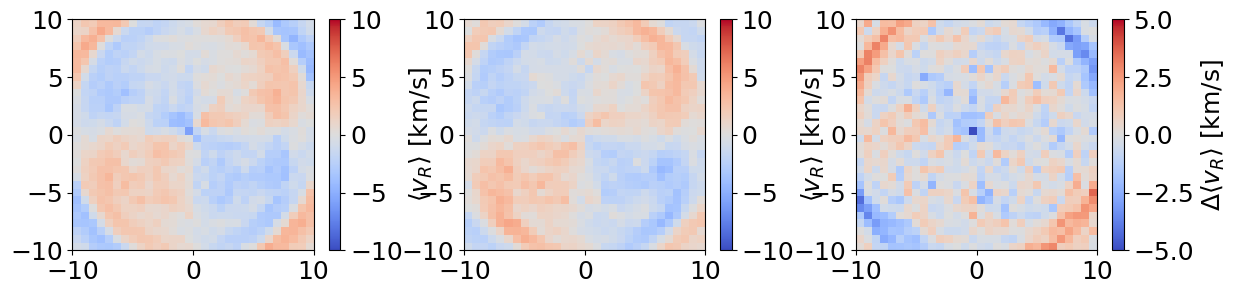

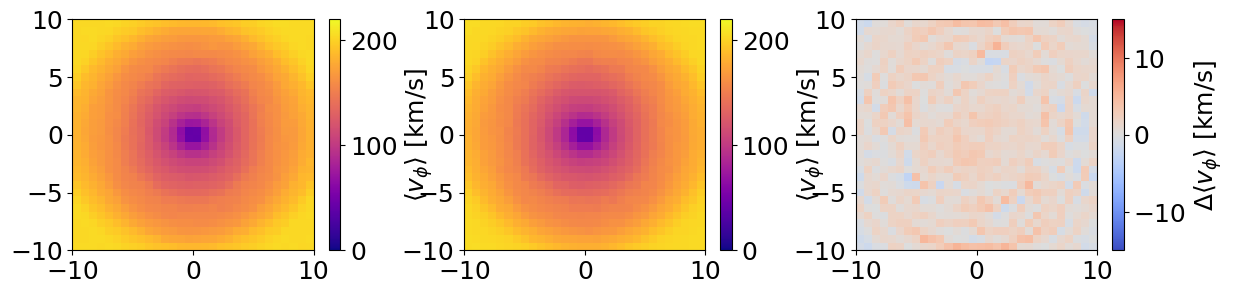

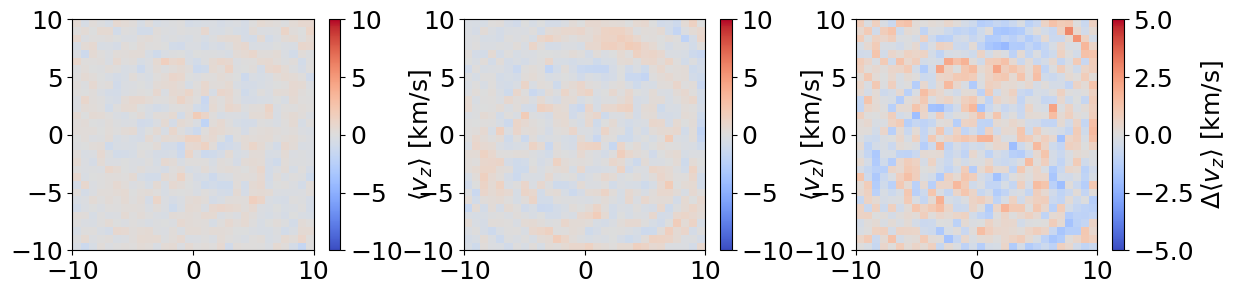

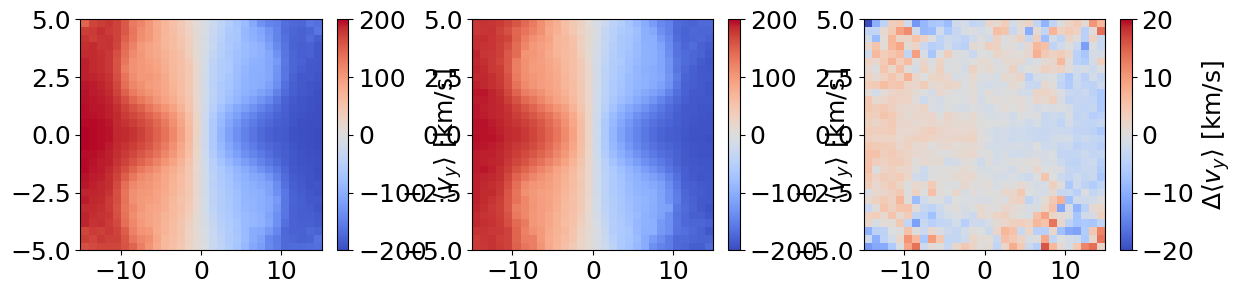

In [22]:
fig, ax = plt.subplots(3,3, figsize=(25,20), gridspec_kw={'wspace':0.3})
H_lf, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=50, range=[[-10, 10], [-10, 10]])
cb = ax[0][0].pcolormesh(xedge, yedge, H_lf.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0][0], label='Number of particles')
ax[0][0].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Leapfrog')
H_agama, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=50, range=[[-10, 10], [-10, 10]])
cb = ax[0][1].pcolormesh(xedge, yedge, H_agama.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0][1], label='Number of particles')
ax[0][1].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Agama')
cb = ax[0][2].pcolormesh(xedge, yedge, ((H_lf - H_agama) / (H_lf + H_agama)/2 + 1e-10).T, cmap='coolwarm', vmax = 0.1, vmin = -0.1)
plt.colorbar(cb, ax=ax[0][2], label='Relative difference')
ax[0][2].set(xlabel='x [kpc]', ylabel='y [kpc]', title='Relative difference')

H_lf, xedge, yedge = np.histogram2d(x_lf, z_lf, bins=50, range=[[-10, 10], [-5, 5]])
cb = ax[1][0].pcolormesh(xedge, yedge, H_lf.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1][0], label='Number of particles')
ax[1][0].set(xlabel='x [kpc]', ylabel='z [kpc]', title='Leapfrog')
H_agama, xedge, yedge = np.histogram2d(x_agama, z_agama, bins=50, range=[[-10, 10], [-5, 5]])
cb = ax[1][1].pcolormesh(xedge, yedge, H_agama.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1][1], label='Number of particles')
ax[1][1].set(xlabel='x [kpc]', ylabel='z [kpc]', title='Agama')
cb = ax[1][2].pcolormesh(xedge, yedge, ((H_lf - H_agama) / (H_lf + H_agama)/2 + 1e-10).T, cmap='coolwarm', vmax = 0.1, vmin = -0.1)
plt.colorbar(cb, ax=ax[1][2], label='Relative difference')
ax[1][2].set(xlabel='x [kpc]', ylabel='z [kpc]', title='Relative difference')

H_lf, xedge, yedge = np.histogram2d(y_lf, z_lf, bins=50, range=[[-10, 10], [-5, 5]])
cb = ax[2][0].pcolormesh(xedge, yedge, H_lf.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2][0], label='Number of particles')
ax[2][0].set(xlabel='y [kpc]', ylabel='z [kpc]', title='Leapfrog')
H_agama, xedge, yedge = np.histogram2d(y_agama, z_agama, bins=50, range=[[-10, 10], [-5, 5]])
cb = ax[2][1].pcolormesh(xedge, yedge, H_agama.T, cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2][1], label='Number of particles')
ax[2][1].set(xlabel='y [kpc]', ylabel='z [kpc]', title='Agama')
cb = ax[2][2].pcolormesh(xedge, yedge, ((H_lf - H_agama) / (H_lf + H_agama)/2 + 1e-10).T, cmap='coolwarm', vmax = 0.1, vmin = -0.1)
plt.colorbar(cb, ax=ax[2][2], label='Relative difference')
ax[2][2].set(xlabel='y [kpc]', ylabel='z [kpc]', title='Relative difference')
plt.show()



fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]])
H_vR_lf = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]], weights=vR_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_vR_lf.T, cmap='coolwarm', vmin = -10, vmax = 10)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_R \rangle$ [km/s]')

H_xy, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]])
H_vR_agama = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]], weights=vR_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_vR_agama.T, cmap='coolwarm', vmin = -10, vmax = 10)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_R \rangle$ [km/s]')

cb = ax[2].pcolormesh(xedge, yedge, (H_vR_lf - H_vR_agama).T, cmap='coolwarm', vmin = -5, vmax = 5)
plt.colorbar(cb, ax=ax[2], label=r'$\Delta \langle v_R \rangle$ [km/s]')
plt.show()

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]])
H_vphi_lf = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]], weights=vphi_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_vphi_lf.T, cmap='plasma', vmin = 0, vmax = 220)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_\phi \rangle$ [km/s]')

H_xy, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]])
H_vphi_agama = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]], weights=vphi_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_vphi_agama.T, cmap='plasma', vmin = 0, vmax = 220)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_\phi \rangle$ [km/s]')

cb = ax[2].pcolormesh(xedge, yedge, (H_vphi_lf - H_vphi_agama).T, cmap='coolwarm', vmin = -15, vmax = 15)
plt.colorbar(cb, ax=ax[2], label=r'$\Delta \langle v_\phi \rangle$ [km/s]')
plt.show()

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]])
H_z_lf = np.histogram2d(x_lf, y_lf, bins=30, range=[[-10, 10], [-10, 10]], weights=vz_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_z_lf.T, cmap='coolwarm', vmin = -10, vmax = 10)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_z \rangle$ [km/s]')

H_xy, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]])
H_z_agama = np.histogram2d(x_agama, y_agama, bins=30, range=[[-10, 10], [-10, 10]], weights=vz_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_z_agama.T, cmap='coolwarm', vmin = -10, vmax = 10)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_z \rangle$ [km/s]')

cb = ax[2].pcolormesh(xedge, yedge, (H_z_lf - H_z_agama).T, cmap='coolwarm', vmin = -5, vmax = 5)
plt.colorbar(cb, ax=ax[2], label=r'$\Delta \langle v_z \rangle$ [km/s]')
plt.show()


fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_lf, z_lf, bins=30, range=[[-15, 15], [-5, 5]])
H_z_lf = np.histogram2d(x_lf, z_lf, bins=30, range=[[-15, 15], [-5, 5]], weights=vy_lf)[0] / H_xy
cb = ax[0].pcolormesh(xedge, yedge, H_z_lf.T, cmap='coolwarm', vmin = -200, vmax = 200)
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_y \rangle$ [km/s]')

H_xy, xedge, yedge = np.histogram2d(x_agama, z_agama, bins=30, range=[[-15, 15], [-5, 5]])
H_z_agama = np.histogram2d(x_agama, z_agama, bins=30, range=[[-15, 15], [-5, 5]], weights=vy_agama)[0] / H_xy
cb = ax[1].pcolormesh(xedge, yedge, H_z_agama.T, cmap='coolwarm', vmin = -200, vmax = 200)
plt.colorbar(cb, ax=ax[1], label=r'$\langle v_y \rangle$ [km/s]')

cb = ax[2].pcolormesh(xedge, yedge, (H_z_lf - H_z_agama).T, cmap='coolwarm', vmin = -20, vmax = 20)
plt.colorbar(cb, ax=ax[2], label=r'$\Delta \langle v_y \rangle$ [km/s]')
plt.show()

In [54]:
import scipy as sp

def construct_potential_slowing_Dillamore24(omega0 = 100, ita = 0.0036, t0= 1, t1 = 2.5, t2 = 3.5, omega_final = 34):

    '''
    t0: the time when the bar starts to grow
    t1: the time when the bar reaches its maximum strength and starts to slow down
    t2: the time when the bar stars to slow down with a constant rate "ita"
    '''

    pot = agama.Potential("/Users/hanyuan/Desktop/PhD_projects/Agama-master/data/Portail17.ini")
    pot_axi = agama.Potential(type='CylSpline', potential=pot, mmax=0)

    def func_pot_diff(xyz):
        val = pot.potential(xyz) - pot_axi.potential(xyz)
        return val

    def amp_time_varying(t, t0, t1):

        eps = 2*(t-t0)/(t1-t0) - 1

        val_left = 0
        val_in_range = 3/16*eps**5 - 5/8*eps**3 + 15/16*eps + 1/2
        val_right = 1

        val = np.where(t<t0, val_left, val_in_range)
        val = np.where(t>t1, val_right, val)

        return val
    
    def length_time_varying(omegat):

        return (39/omegat)
    
    def Omega_t(t, omega0, ita, t1, t2,):

        omega2 = omega0*(1+1/2*ita*omega0*(t2-t1))**(-1)

        omega_lesst1 = np.ones_like(t)*omega0
        omega_t1t2 = omega0*(1+1/2*ita*omega0*(t-t1)**2/(t2-t1))**(-1)
        omega_greatt2 = omega2*(1+ita*omega2*(t-t2))**(-1)

        omega = np.where(t<t1, omega_lesst1, omega_t1t2)
        omega = np.where(t>t2, omega_greatt2, omega)

        return omega
    
    def angle_diff_time_varying(t,_t, t1, t2, omega0, ita):

        omega_t = Omega_t(t, omega0, ita, t1, t2)

        angle_diff = omega_t*(t-_t)

        return angle_diff


    pot_diff = agama.Potential(type="CylSpline", potential=func_pot_diff,
                gridSizeR=30, gridSizez=25, Rmin=0.1, Rmax=50, zmin=0.05, zmax=20,
                mmax=8, symmetry = "none")

    t_stamp = np.linspace(0, 10, 200)

    # mass_normalisation = amp_time_varying(t_stamp, t0, t1)

    # omega = omega
    bar_scale1 = np.array([[t, amp_time_varying(t, t0, t1), length_time_varying(Omega_t(t, omega0, ita, t1, t2))] for t in t_stamp])
    # mass_scale_spl1 = agama.Spline(bar_scale1[:,0], bar_scale1[:,1], reg=True)

    angle0 = 0
    t_1 = t0
    t_interp = [0, t_1]
    angles = [angle0, angle0]
    for t in np.arange(t0+0.001, 15, 0.001):
        delta_angle = angle_diff_time_varying(t, t_1, t1, t2, omega0, ita)
        if delta_angle/0.001>omega_final:
            angle0+=delta_angle
        else:
            angle0+=omega_final*0.001
        angles.append(angle0)
        t_interp.append(t)
        t_1 = t
    
    rot_angle = np.array([t_interp,angles]).T
    rot_angle[:,1] = -rot_angle[:,1] # Make it rotate clockwise
    rot_angle_interp = sp.interpolate.interp1d(rot_angle[:,0], rot_angle[:,1])

    pot_growing = agama.Potential(potential=pot_diff, rotation=rot_angle, scale=bar_scale1,)# Omega = 40
    pot_final = agama.Potential(pot_growing, pot_axi)

    return pot_final, pot_axi, rot_angle_interp


10000 orbits complete (384.6 orbits/s)                  
100%|██████████| 10000/10000 [00:00<00:00, 575500.34it/s]


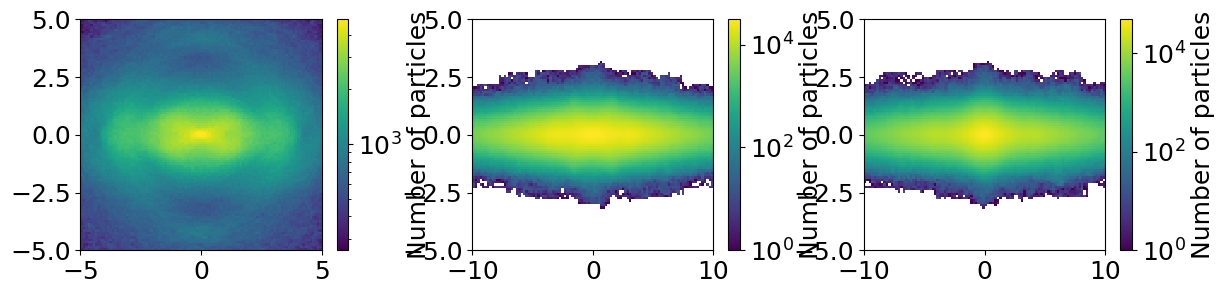

In [ ]:
def getCylindricalFromCartesian_clockwise(x, y, vx, vy):
    R = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    vR = (x*vx + y*vy) / R
    vphi = (x*vy - y*vx) / R
    return R, phi, vR, vphi

pot_final, pot_axi, rot_angle_interp = construct_potential_slowing_Dillamore24(
    omega0 = 34, ita = 0., t0= 0.01, t1 = 1, t2 = 1.5, omega_final = 34)
# pot_portail_axi = agama.Potential('/Users/hanyuan/Desktop/PhD_projects/Agama-master/data/McMillan17.ini')
pot_bar = agama.Potential("/Users/hanyuan/Desktop/PhD_projects/Agama-master/data/Portail17.ini")
af = agama.ActionFinder(pot_axi)
df = agama.DistributionFunction(type = 'QuasiIsothermal', potential = pot_axi, 
                                Sigma0 = 1, Rdisk = 3.0, Hdisk = 0.3, sigmar0 = 80, Rsigmar = 5)
gm = agama.GalaxyModel(potential = pot_axi, df = df)
posvel, _ = gm.sample(int(1e4))
posvel[:,0] = -posvel[:,0]
posvel[:,3] = -posvel[:,3]

result_agama = agama.orbit(potential=pot_bar, ic=posvel, time=3, trajsize = 2000, Omega = -34)

x_agama, y_agama, z_agama = [], [], []
vx_agama, vy_agama, vz_agama = [], [], []
for i, (times, trj) in tqdm(enumerate(result_agama), total = len(result_agama)):

    x_agama.append(trj[:,0])
    y_agama.append(trj[:,1])
    z_agama.append(trj[:,2])
    vx_agama.append(trj[:,3])
    vy_agama.append(trj[:,4])
    vz_agama.append(trj[:,5])

x_agama = np.array(x_agama).flatten()
y_agama = np.array(y_agama).flatten()
z_agama = np.array(z_agama).flatten()
vx_agama = np.array(vx_agama).flatten()
vy_agama = np.array(vy_agama).flatten()
vz_agama = np.array(vz_agama).flatten()

R, phi, vR, vphi = getCylindricalFromCartesian_clockwise(posvel[:,0], posvel[:,1], posvel[:,3], posvel[:,4])

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge, cb = ax[0].hist2d(x_agama, y_agama, bins=100, range=[[-5, 5], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0], label='Number of particles')
_, _, _, cb = ax[1].hist2d(x_agama, z_agama, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1], label='Number of particles')
_, _, _, cb = ax[2].hist2d(y_agama, z_agama, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2], label='Number of particles')
plt.show()

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_vR, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=100, range=[[-5, 5], [-5, 5]], weights=vR)

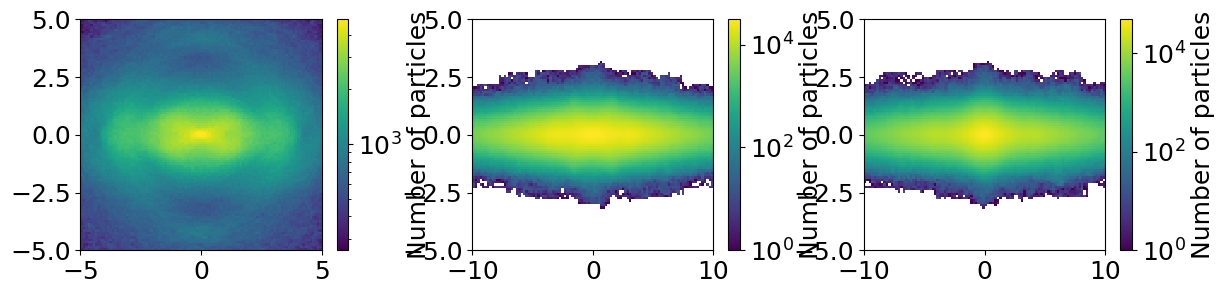

/var/folders/sy/hx8cmv810rq7tfr6nkmnhg3w0000gn/T/ipykernel_82225/3207036368.py:22: UserWarning: Adding colorbar to a different Figure <Figure size 1400x300 with 6 Axes> than <Figure size 1400x300 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(cb, ax=ax[0], label=r'$\langle v_R \rangle$ [km/s]')


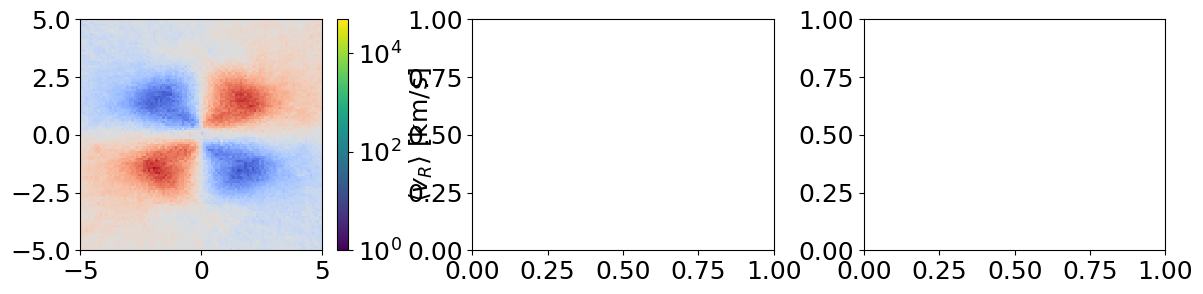

In [69]:
def getCylindricalFromCartesian_clockwise(x, y, vx, vy):
    R = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    vR = (x*vx + y*vy) / R
    vphi = (x*vy - y*vx) / R
    return R, phi, vR, vphi
R, phi, vR, vphi = getCylindricalFromCartesian_clockwise(x_agama, y_agama, vx_agama, vy_agama)

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge, cb = ax[0].hist2d(x_agama, y_agama, bins=100, range=[[-5, 5], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0], label='Number of particles')
_, _, _, cb = ax[1].hist2d(x_agama, z_agama, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1], label='Number of particles')
_, _, _, cb = ax[2].hist2d(y_agama, z_agama, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2], label='Number of particles')
plt.show()

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
H_xy, xedge, yedge = np.histogram2d(x_agama, y_agama, bins=100, range=[[-5, 5], [-5, 5]])
H_vR = np.histogram2d(x_agama, y_agama, bins=100, range=[[-5, 5], [-5, 5]], weights=vR)[0] / H_xy
ax[0].pcolormesh(xedge, yedge, H_vR.T, cmap='coolwarm')
plt.colorbar(cb, ax=ax[0], label=r'$\langle v_R \rangle$ [km/s]')

100%|██████████| 10000/10000 [00:03<00:00, 2835.36it/s]


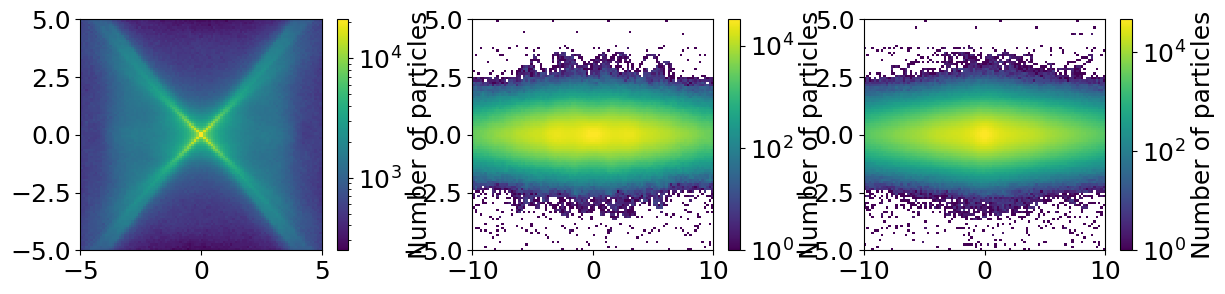

In [60]:
@jax.jit
def bar_frame(xv, angle):
    # Rotate contourclockwise with positive angle
    sina, cosa = jnp.sin(angle), jnp.cos(angle)
    xv = xv.at[:,0].set(xv[:,0]*cosa-xv[:,1]*sina)
    xv = xv.at[:,1].set(xv[:,0]*sina+xv[:,1]*cosa)
    xv = xv.at[:,3].set(xv[:,3]*cosa-xv[:,4]*sina)
    xv = xv.at[:,4].set(xv[:,3]*sina+xv[:,4]*cosa)
    return xv

x_agama, y_agama, z_agama = [], [], []
vx_agama, vy_agama, vz_agama = [], [], []
for i, (times, trj) in tqdm(enumerate(result_agama), total = len(result_agama)):

    bar_frameed_trj = bar_frame(trj, -rot_angle_interp(times))

    x_agama.append(bar_frameed_trj[:,0])
    y_agama.append(bar_frameed_trj[:,1])
    z_agama.append(bar_frameed_trj[:,2])
    vx_agama.append(bar_frameed_trj[:,3])
    vy_agama.append(bar_frameed_trj[:,4])
    vz_agama.append(bar_frameed_trj[:,5])

x_agama = np.array(x_agama).flatten()
y_agama = np.array(y_agama).flatten()
z_agama = np.array(z_agama).flatten()
vx_agama = np.array(vx_agama).flatten()
vy_agama = np.array(vy_agama).flatten()
vz_agama = np.array(vz_agama).flatten()

fig, ax = plt.subplots(1,3, figsize=(14,3), gridspec_kw={'wspace':0.3})
_, _, _, cb = ax[0].hist2d(x_agama, y_agama, bins=100, range=[[-5, 5], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[0], label='Number of particles')
_, _, _, cb = ax[1].hist2d(x_agama, z_agama, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[1], label='Number of particles')
_, _, _, cb = ax[2].hist2d(y_agama, z_agama, bins=100, range=[[-10, 10], [-5, 5]], cmap='viridis', norm='log')
plt.colorbar(cb, ax=ax[2], label='Number of particles')
plt.show()

False


100%|██████████| 400/400 [00:40<00:00,  9.92it/s]


Best-fit parameters:
R_d: 4.8519
h_z: 0.4160
log10 rho0: 8.4171
log10 M_bar: 10.5152
R_s: 1.8924
p: 0.5485
q: 0.6249

Sampling particles from best-fit density distribution...


100%|██████████| 243000/243000 [01:41<00:00, 2387.16it/s]
/tmp/ipykernel_3264069/4271078576.py:479: RuntimeWarning: divide by zero encountered in divide
  residual = (H - H_model) / H
/tmp/ipykernel_3264069/4271078576.py:496: RuntimeWarning: divide by zero encountered in divide
  H_den = H / (2 * np.pi * xegde[:-1] * (xegde[1]-xegde[0]))
/tmp/ipykernel_3264069/4271078576.py:499: RuntimeWarning: divide by zero encountered in divide
  H_model_den = H_model / (2 * np.pi * xegde[:-1] * (xegde[1]-xegde[0]))


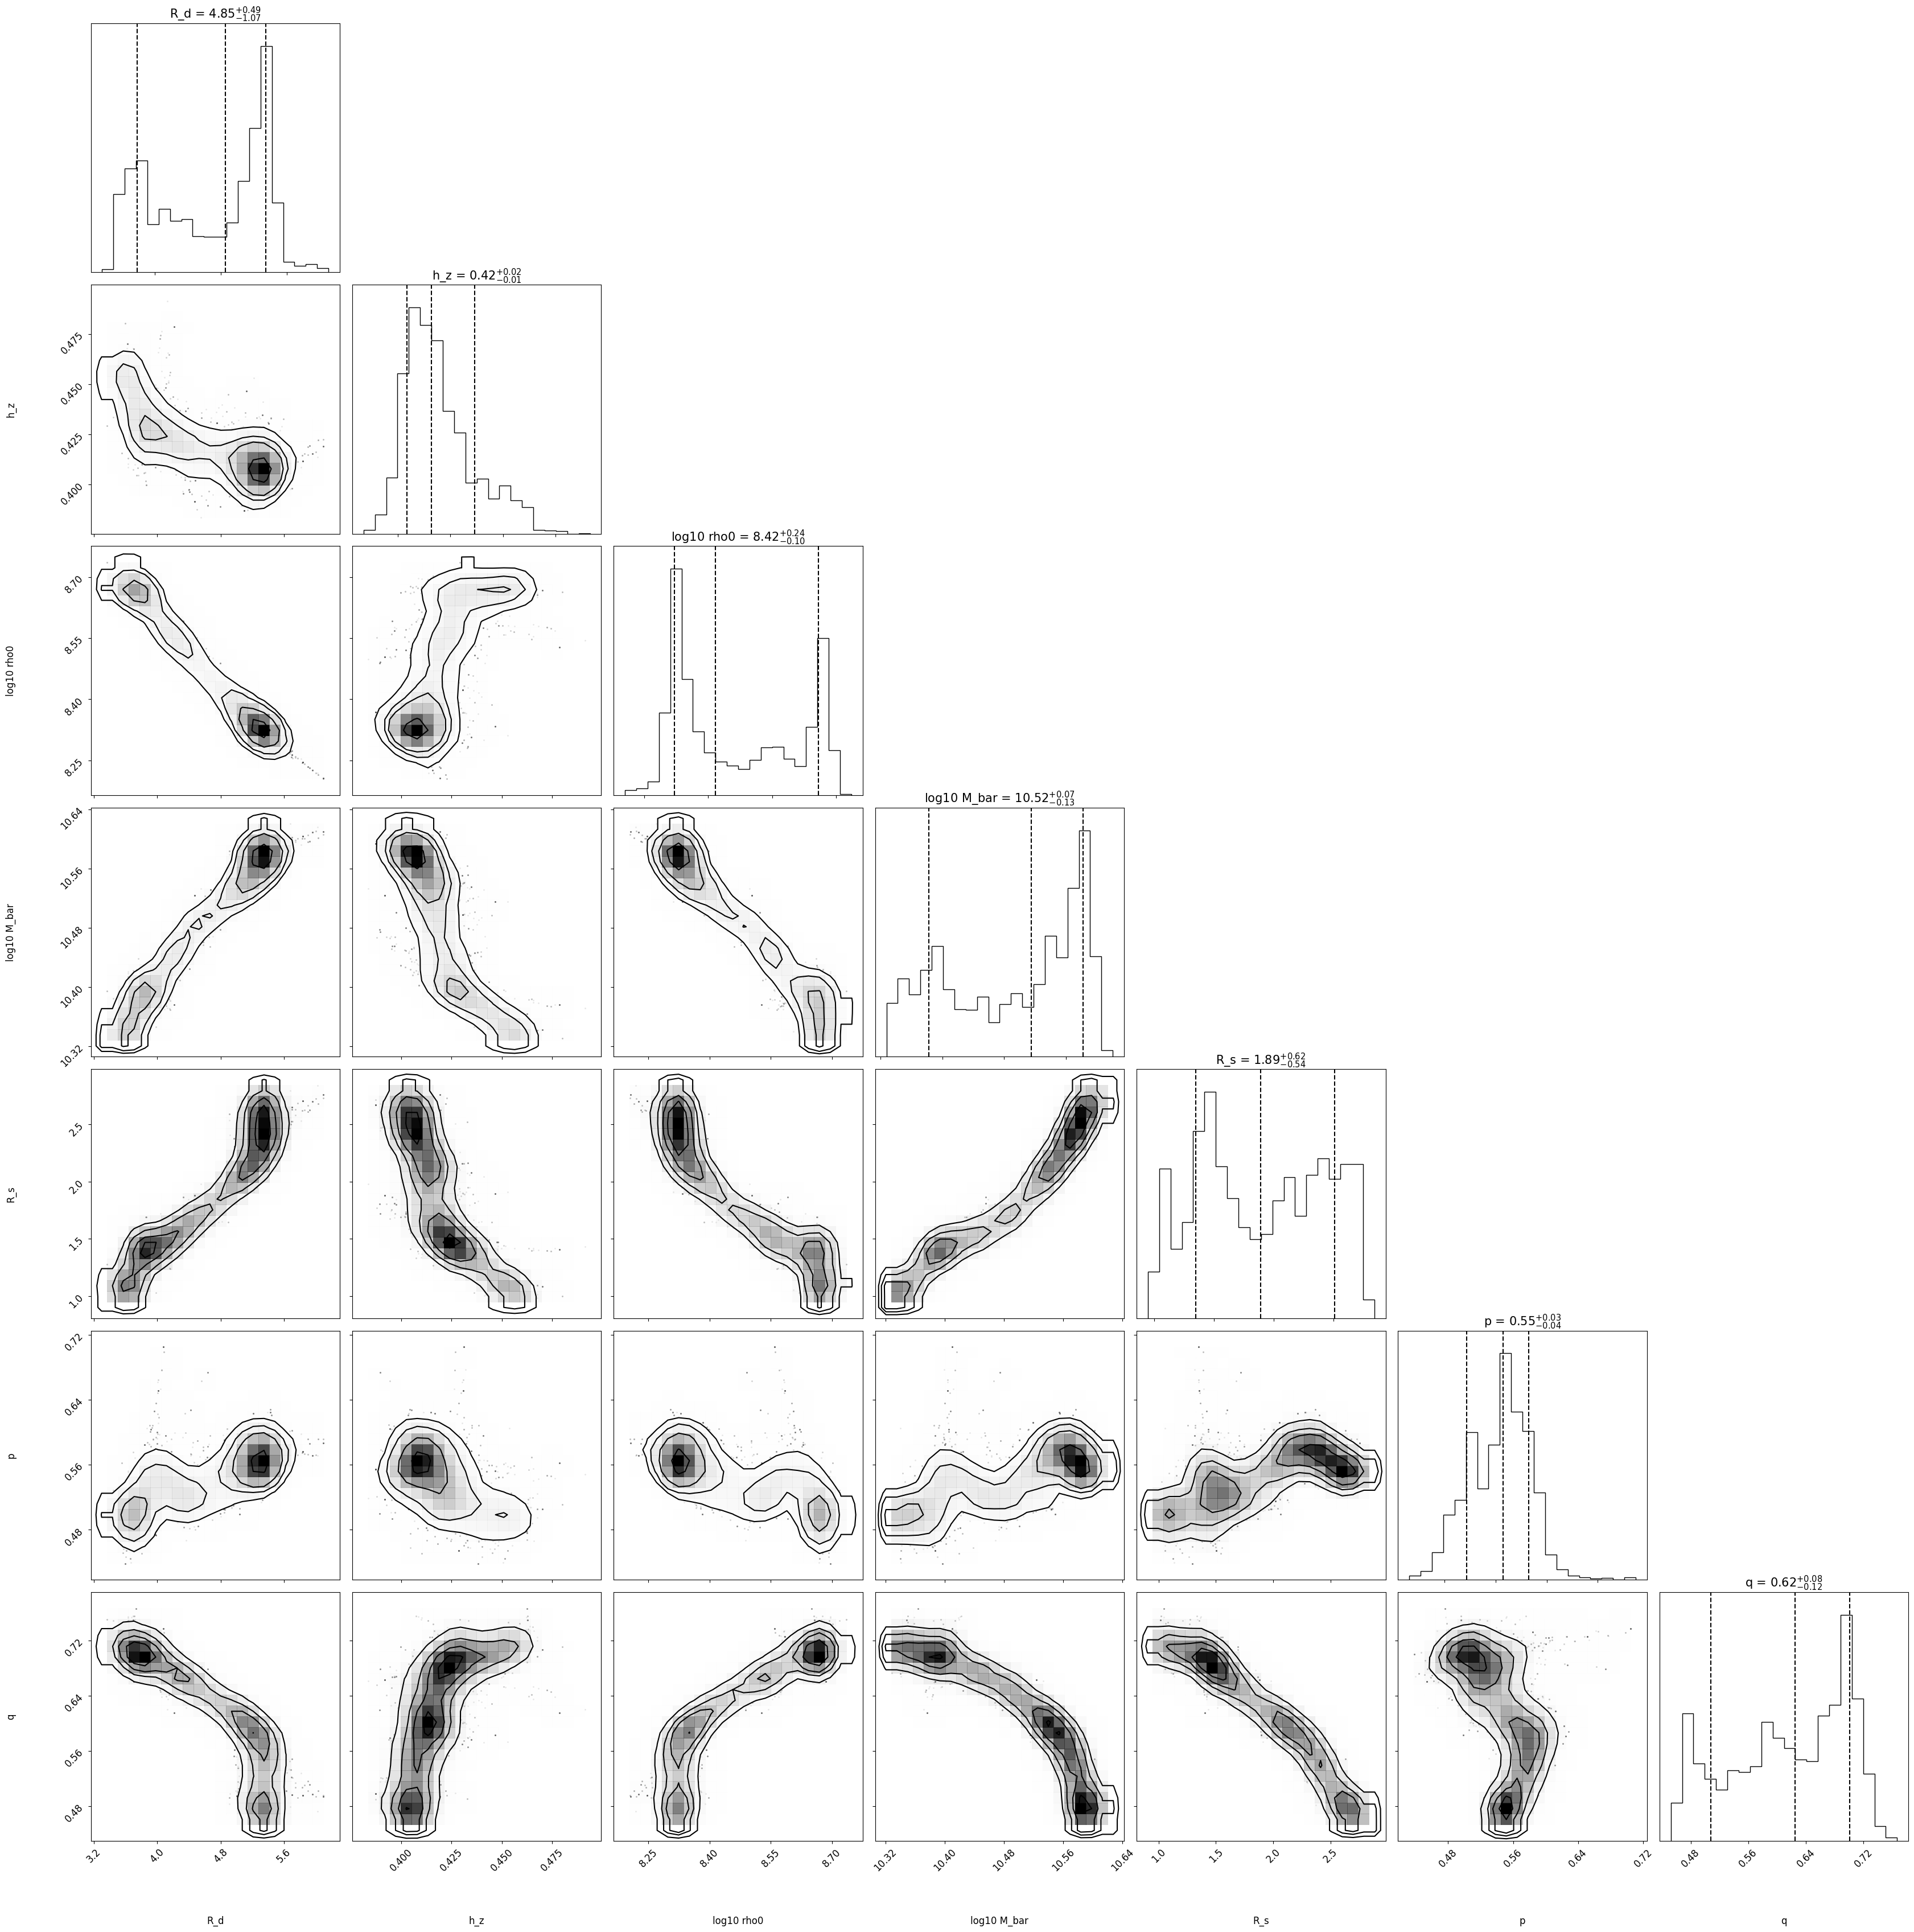

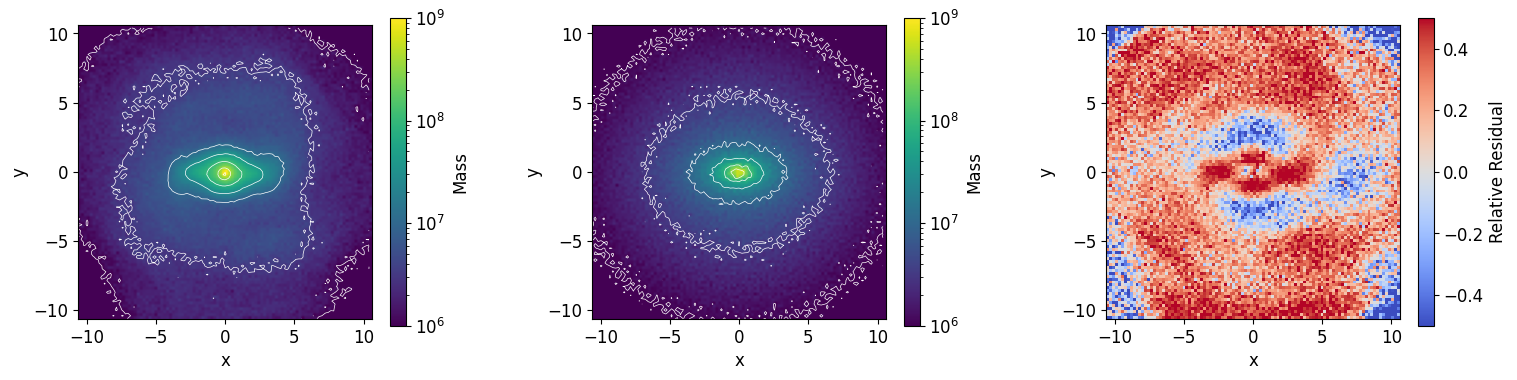

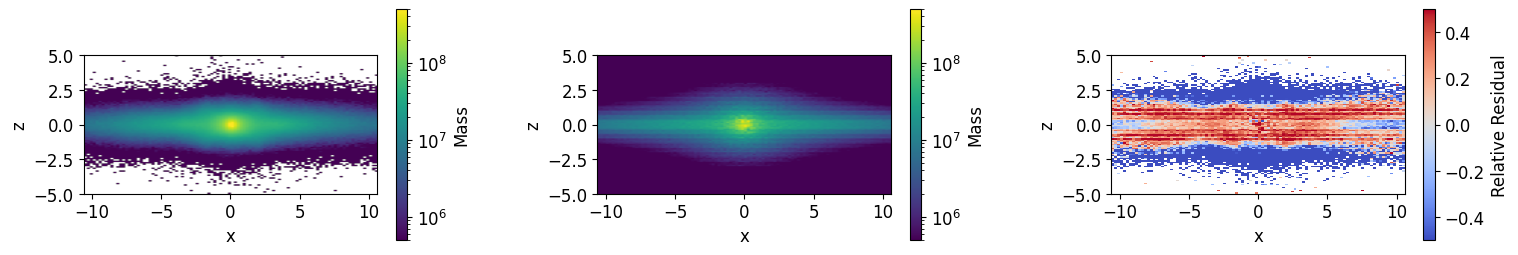

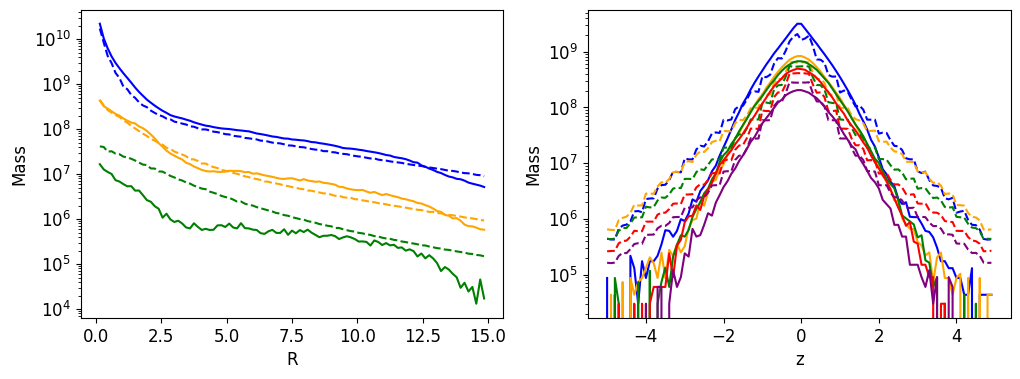

In [65]:
path = '/home/hz420/python_script/SchwarMAX/'

import sys
sys.path.append(path)

import numpy as np
import scipy as sp
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 12
from potentials import *
from densities import *
from sample_from_density import sample_from_density_grid
import emcee
import corner
import agama
agama.setUnits(length=1, velocity=1, mass=1)

from astropy.constants import G
import astropy.units as u

from multiprocessing import Pool, cpu_count
from functools import partial

def sample_from_density_grid(
    density_fn,
    params,
    bounds,
    n_samples,
    n_x=96,
    n_y=96,
    n_z=64,
):
    """
    JAX-jittable generic sampler from a 3D density via grid-based inverse-CDF.

    Works well for cuspy profiles where naive rejection from a wide uniform box
    becomes inefficient.

    Parameters
    ----------
    key : PRNGKey
    density_fn : callable
        Signature density_fn(x, y, z, params) -> rho.
    params : pytree
        Density parameters.
    bounds : array (3,2)
        [[xmin,xmax], [ymin,ymax], [zmin,zmax]].
    n_samples : int
        Number of particles.
    n_x, n_y, n_z : int
        Grid resolution used to discretize rho.
    """
    bounds = jnp.asarray(bounds, dtype=jnp.float32)

    x_edges = jnp.linspace(bounds[0, 0], bounds[0, 1], n_x + 1)
    y_edges = jnp.linspace(bounds[1, 0], bounds[1, 1], n_y + 1)
    z_edges = jnp.linspace(bounds[2, 0], bounds[2, 1], n_z + 1)

    dx = x_edges[1] - x_edges[0]
    dy = y_edges[1] - y_edges[0]
    dz = z_edges[1] - z_edges[0]

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

    X, Y, Z = jnp.meshgrid(x_centers, y_centers, z_centers, indexing="ij")
    X, Y, Z = X.ravel(), Y.ravel(), Z.ravel()

    rho = density_fn(X, Y, Z, params)
    rho = jnp.nan_to_num(rho, nan=0.0, posinf=0.0, neginf=0.0)
    rho = jnp.clip(rho, a_min=0.0)

    cell_mass = rho * dx * dy * dz
    flat_mass = cell_mass

    total_mass = flat_mass.sum()
    N_sample_per_cell = int(n_samples / (n_x * n_y * n_z))
    # print(N_sample_per_cell)
    x_samples = []
    y_samples = []
    z_samples = []
    m_samples = []
    for i in tqdm(range(len(flat_mass))):
        x0 = X[i]
        y0 = Y[i]
        z0 = Z[i]

        x_samples.append(x0 + dx * (np.random.uniform(-0.5, 0.5, size=(N_sample_per_cell))))
        y_samples.append(y0 + dy * (np.random.uniform(-0.5, 0.5, size=(N_sample_per_cell))))
        z_samples.append(z0 + dz * (np.random.uniform(-0.5, 0.5, size=(N_sample_per_cell))))

        m_samples.append((flat_mass[i] / N_sample_per_cell) * jnp.ones(N_sample_per_cell))

    x_samples = jnp.concatenate(x_samples)
    y_samples = jnp.concatenate(y_samples)
    z_samples = jnp.concatenate(z_samples)
    m_samples = jnp.concatenate(m_samples)

    samples = jnp.stack([x_samples, y_samples, z_samples], axis=1)
    mass_per_particle = m_samples

    return {
        "samples": samples,
        'mass_per_particle': mass_per_particle,
        "cell_mass_grid": cell_mass,
    }



def gaussian(x, mu, sigma):
    return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def bar_angle_bar_strength(x, y, R_anulus = np.arange(1,5,0.25)):

    ''' 
    Calculate the angle and strength of the dipole strength in each radial bin.
    Parameters:
        x, y - ndarray, Cartesian coordinates of the stars
        R_anulus - ndarray, edges of the radial bins to use for calculating the dipole angle and strength
    Returns:
        R_mid - ndarray, midpoints of the radial bins
        bar_angles0 - ndarray, angles of the dipole strength in each radial bin
        bar_strength0 - ndarray, strengths of the dipole strength in each radial bin

    '''

    R0,phi0 = np.sqrt(x**2 + y**2), np.arctan2(y,x)

    bar_angles0 = []
    bar_strength0 = []
    R_anulus = R_anulus
    for i in range(len(R_anulus)-1):
        sel0 = (R0>R_anulus[i]) & (R0<R_anulus[i+1])

        r_min_i = (R_anulus[i]+R_anulus[i+1])/2
        
        R0_bin, phi0_bin = R0[sel0], phi0[sel0]

        A2_0 = np.sum(np.cos(2*phi0_bin))/len(phi0_bin)
        B2_0 = np.sum(np.sin(2*phi0_bin))/len(phi0_bin)

        angle_bar0 = 0.5*np.arctan2(B2_0,A2_0)
        bar_strength = np.sqrt(A2_0**2 + B2_0**2)

        bar_angles0.append(angle_bar0)
        bar_strength0.append(bar_strength
                             )
    R_mid = (R_anulus[:-1]+R_anulus[1:])/2
    bar_angles0 = np.array(bar_angles0)
    bar_strength0 = np.array(bar_strength0)

    return R_mid, bar_angles0, bar_strength0

def rotate(posvel, angle):
    # Rotate contourclockwise with positive angle
    x, y, z, vx, vy, vz = posvel.T
    sina, cosa = np.sin(angle), np.cos(angle)
    return np.array([x*cosa-y*sina, x*sina+y*cosa, z, vx*cosa-vy*sina, vx*sina+vy*cosa, vz]).T



def XexpX_pdf_log(x, a):
    """
    Probability density function of the distribution proportional to x * exp(-x/a).
    
    Parameters
    ----------
    x : array_like
        Points at which to evaluate the PDF. Can be scalar or array.
    a : float
        Scale parameter > 0.
    
    Returns
    -------
    pdf : array_like
        The PDF values at x.
    """
    # Ensure a > 0
    a = jnp.asarray(a)
    # PDF formula: (1/a^2) * x * exp(-x/a)
    pdf = jnp.log(x) - jnp.log(a**2) - (x / a)
    return jnp.where(x >= 0, pdf, -jnp.inf)


@partial(jax.jit,static_argnums=(2))
def sample_from_logP(x_grid, logP, N, key):
    """
    Draw N samples from the distribution defined by logP on the grid x_grid
    using the inverse‐CDF method.
    """
    # 1) Shift & exponentiate for numerical stability
    logP = jnp.asarray(logP)
    logP = logP - jnp.max(logP)
    P = jnp.exp(logP)

    # 2) Normalize to get a proper probability mass on the grid
    P /= P.sum()

    # 3) Build the CDF
    cdf = jnp.cumsum(P)

    # 4) Sample uniforms and invert the CDF via linear interpolation
    # jax_random_key2 = jax.random.PRNGKey(random_seed)
    u = jax.random.uniform(key, shape=(N,))
    samples = jnp.interp(u, cdf, x_grid)
    return samples



from scipy.stats import qmc
sampler = qmc.Sobol(d=3, scramble=False)
sample_mc = sampler.random_base2(m=10)
sample_mc_x = jax.scipy.special.ndtri(sample_mc[1:,0]) * 8
sample_mc_y = jax.scipy.special.ndtri(sample_mc[1:,1]) * 8
sample_mc_z = jax.scipy.special.ndtri(sample_mc[1:,2]) * 3

posvel, mass = agama.readSnapshot(f'/data/hz420-2/SchwarMAX/Bar_model_TG21/model/t_t0_2.5')
mask = (mass!=np.unique(mass)[-1])
posvel = posvel[mask]
mass = mass[mask]

posvel[:,0] = posvel[:,0] - np.mean(posvel[:,0])
posvel[:,1] = posvel[:,1] - np.mean(posvel[:,1])
posvel[:,2] = posvel[:,2] - np.mean(posvel[:,2])
posvel[:,3] = posvel[:,3] - np.mean(posvel[:,3])
posvel[:,4] = posvel[:,4] - np.mean(posvel[:,4])
posvel[:,5] = posvel[:,5] - np.mean(posvel[:,5])

posvel[:,0] = -posvel[:,0]
posvel[:,3] = -posvel[:,3]

R_mid, bar_angles0, bar_strength0 = bar_angle_bar_strength(posvel[:,0], posvel[:,1], R_anulus = np.arange(1,5,0.25))
bar_angle0 = np.mean(bar_angles0[R_mid<4])
rot_angle = -bar_angle0
posvel = rotate(posvel, rot_angle)  # rotate to make it anticlockwise


R = np.sqrt(posvel[:,0]**2 + posvel[:,1]**2)
z = posvel[:,2]

mass_factor = 1/((G*u.Msun).to(u.kpc*(u.km/u.s)**2))
mass = mass * mass_factor.value

Rmax, zmax = 15, 5
xmax = Rmax / np.sqrt(2)
mask = (R < Rmax) & (np.abs(z) < zmax)
posvel = posvel[mask]
mass = mass[mask]

R = R[mask]
z = z[mask]

data = {
    'x': posvel[:,0],
    'y': posvel[:,1],
    'z': posvel[:,2],
    'mass': mass
}

mass_cell, (xedge, yedge, zedge) = np.histogramdd((data['x'], data['y'], data['z']), bins=(100, 100, 50), range=[[-xmax,xmax],[-xmax,xmax],[-zmax,zmax]], weights=data['mass'])
mass2_cell,_ = np.histogramdd((data['x'], data['y'], data['z']), bins=(100, 100, 50), range=[[-xmax,xmax],[-xmax,xmax],[-zmax,zmax]], weights=data['mass']**2)
mass_err_cell = np.sqrt(mass2_cell)
dx, dy, dz = xedge[1]-xedge[0], yedge[1]-yedge[0], zedge[1]-zedge[0]
density_cell = mass_cell / (dx * dy * dz)
density_err_cell = mass_err_cell / (dx * dy * dz)
xmid, ymid, zmid = 0.5*(xedge[:-1] + xedge[1:]), 0.5*(yedge[:-1] + yedge[1:]), 0.5*(zedge[:-1] + zedge[1:])
x_grid, y_grid, z_grid = np.meshgrid(xmid, ymid, zmid, indexing='ij')

pos_grid = np.column_stack([x_grid.ravel(), y_grid.ravel(), z_grid.ravel()])
density_grid = density_cell.ravel()
density_err_grid = density_err_cell.ravel()

mask = density_grid > 0
pos_grid = pos_grid[mask]
density_grid = density_grid[mask]
density_err_grid = density_err_grid[mask]
print(True in np.isnan(density_grid))

@jax.jit
def Dehnen_density(x, y, z, params):

    '''
    Dehnen profile: rho = (M / (4π p q Rs^3)) * (r/Rs)^(-n) * (1 + r/Rs)^(n-4), where n = 2
    '''

    p, q, Rs = params['p_bar'], params['q_bar'], params['Rs_bar']
    M = 10.0 ** params['logM_bar']
    r = jnp.sqrt(x**2 + (y / p)**2 + (z / q)**2)

    val = M / (4 * jnp.pi * p * q * Rs**3) * (r / Rs)**(-2) * (1 + r / Rs)**(-2) * jnp.exp(-(z / 3)**2)

    return val

def density_func(x, y, z, params):

    R = jnp.sqrt(x**2 + y**2)

    val = DoubleExponentialDisk_density(x, y, z, params) + Dehnen_density(x, y, z, params)#
    return val #jnp.where((R < Rmax) & (jnp.abs(z) < zmax), val, 0.0)

def log_prior(theta,):
    if (-1 < theta[0] < 2) and (-1 < theta[1] < 1) and (7 < theta[2] < 11) and \
    (8 < theta[3] < 12) and (-1 < theta[4] < 1) and (-2 < theta[5] < 0) and (-2 < theta[6] < 0):
        return 0.0  # log(1) = 0 for uniform prior
    return -np.inf  # log(0) = -inf for out-of-bounds

def log_prob(theta,):
    # print(theta)
    ll = log_prior(theta)
    if not np.isfinite(ll):
        return -np.inf

    x,y,z = pos_grid[:,0], pos_grid[:,1], pos_grid[:,2]
    density_data = density_grid

    params = {
        'rho0_disc': 10**theta[2],
        'Rd_disc': 10 ** theta[0],
        'hz_disc': 10 ** theta[1],
        'logM_bar': theta[3],
        'Rs_bar': 10 ** theta[4],
        'p_bar':10 ** theta[5],
        'q_bar':10 ** theta[6],
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    density_model = density_func(x,y,z, params)#

    # print('nan in density_model:', True in np.isnan(density_model))

    residual = (density_model - density_data) / (density_err_grid + 1e-12)

    # print('nan in residual:', True in np.isnan(residual))

    val = -0.5 * np.sum(residual**2)

    # print('nan in val:', val)
    return val

ndim = 7
nwalkers = 32  # must be >= 2 * ndim
p0 = np.array([0, 0, 9, 10, 0, -0.5, -0.5])
initial_pos = p0 + np.random.uniform(-0.2, 0.2, (nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(initial_pos, 400, progress=True)
samples = sampler.get_chain(discard=200, flat=True)
final_params = samples
pd.DataFrame(
    final_params, columns=['log10_Rd','log10_hz','log10_rho0','log10_M','log10_Rs','log10_p','log10_q']
    ).to_csv('/data/hz420-2/SchwarMAX/Bar_model_TG21/model/best_fit_params_binned_stars.csv', index=False)

# final_params = pd.read_csv('/data/hz420-2/SchwarMAX/SCM_disc/model/best_fit_params.csv').to_numpy()

fig, ax = plt.subplots(7, 7, figsize=(35, 35))
samples_plot = final_params
samples_plot[:,0] = 10 ** samples_plot[:,0]
samples_plot[:,1] = 10 ** samples_plot[:,1]
samples_plot[:,4] = 10 ** samples_plot[:,4]
samples_plot[:,5] = 10 ** samples_plot[:,5]
samples_plot[:,6] = 10 ** samples_plot[:,6]

corner.corner(samples_plot, labels=['R_d','h_z', 'log10 rho0', 'log10 M_bar', 'R_s', 'p', 'q'], 
            show_titles=True, title_fmt='.2f', title_kwargs={"fontsize": 15},
            smooth=True, quantiles=[0.16, 0.5, 0.84], fig=fig)
########################
fig.savefig('/data/hz420-2/SchwarMAX/Bar_model_TG21/model/bar_posterior.png')
########################

best_fit_param = np.percentile(samples_plot, 50, axis=0)
print("Best-fit parameters:")
for i, name in enumerate(['R_d','h_z', 'log10 rho0', 'log10 M_bar', 'R_s', 'p', 'q']):
    print(f"{name}: {best_fit_param[i]:.4f}")

# Sample particles from the best-fit density distribution
print("\nSampling particles from best-fit density distribution...")
Rd_best = best_fit_param[0]
hz_best = best_fit_param[1]
rho_best = 10**best_fit_param[2]
logM_best = best_fit_param[3]
Rs_best = best_fit_param[4]
p_best = best_fit_param[5]
q_best = best_fit_param[6]
params_best = {
        'rho0_disc': rho_best,
        'Rd_disc': Rd_best,
        'hz_disc': hz_best,
        'logM_bar': logM_best,
        'Rs_bar': Rs_best,
        'p_bar': p_best,
        'q_bar': q_best,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }
bounds = jnp.array(
    [
        [-15, 15],  # x
        [-15, 15],  # y
        [-5, 5],    # z
    ],
    dtype=jnp.float32,
)

n_samples = 5_000_000
n_x = 90
n_y = 90
n_z = 30
sample_ic_dict = sample_from_density_grid(
    density_func,
    params_best,
    bounds,
    n_samples=n_samples,
    n_x=n_x,
    n_y=n_y,
    n_z=n_z,
)
sampled_particles = np.asarray(sample_ic_dict["samples"])
mass_samples = sample_ic_dict['mass_per_particle']
R_samples = np.sqrt(sampled_particles[:,0]**2 + sampled_particles[:,1]**2)
z_samples = sampled_particles[:,2]

sampled_particles = np.asarray(sample_ic_dict["samples"])
mass_samples = sample_ic_dict['mass_per_particle']
R_samples = np.sqrt(sampled_particles[:,0]**2 + sampled_particles[:,1]**2)
z_samples = sampled_particles[:,2]

fig, ax = plt.subplots(1,3, figsize=(18,4), gridspec_kw={'wspace':0.4})

H, xedge, yedge = np.histogram2d(posvel[:,0], posvel[:,1], bins=100, range = [[-xmax,xmax],[-xmax,xmax]], weights=mass)
cb = ax[0].imshow(H.T, origin='lower', extent=[xedge[0], xedge[-1], yedge[0], yedge[-1]], norm = 'log', vmin = 1e6, vmax = 1e9)
ax[0].contour(xedge[:-1], yedge[:-1], np.log10(H).T, levels=np.arange(6,9.5,0.5), colors='white', linewidths=0.5,)
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(cb, ax=ax[0], label='Mass')


H_model, xedge, yedge = np.histogram2d(sampled_particles[:,0], sampled_particles[:,1], bins=100, range = [[-xmax,xmax],[-xmax,xmax]], weights=mass_samples)
cb = ax[1].imshow(H_model.T, origin='lower', extent=[xedge[0], xedge[-1], yedge[0], yedge[-1]], norm = 'log', vmin = 1e6, vmax = 1e9)
ax[1].contour(xedge[:-1], yedge[:-1], np.log10(H_model).T, levels=np.arange(6,9.5,0.5), colors='white', linewidths=0.5)
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(cb, ax=ax[1], label='Mass')

residual = (H - H_model) / H
cb = ax[2].pcolormesh(xedge, yedge, residual.T, vmin = -0.5, vmax = 0.5, cmap='coolwarm')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].set_aspect('equal')
plt.colorbar(cb, ax=ax[2], label='Relative Residual')

fig, ax = plt.subplots(1,3, figsize=(18,3), gridspec_kw={'wspace':0.4})

H, xedge, yedge = np.histogram2d(posvel[:,0], posvel[:,2], bins=100, range = [[-xmax,xmax],[-zmax,zmax]], weights=mass)
cb = ax[0].imshow(H.T, origin='lower', extent=[xedge[0], xedge[-1], yedge[0], yedge[-1]], norm = 'log', vmin = 5e5, vmax = 5e8)
ax[0].set_xlabel('x')
ax[0].set_ylabel('z')
plt.colorbar(cb, ax=ax[0], label='Mass')


H_model, xedge, yedge = np.histogram2d(sampled_particles[:,0], sampled_particles[:,2], bins=100, range = [[-xmax,xmax],[-zmax,zmax]], weights=mass_samples)
cb = ax[1].imshow(H_model.T, origin='lower', extent=[xedge[0], xedge[-1], yedge[0], yedge[-1]], norm = 'log', vmin = 5e5, vmax = 5e8)
ax[1].set_xlabel('x')
ax[1].set_ylabel('z')
plt.colorbar(cb, ax=ax[1], label='Mass')

residual = (H - H_model) / H
cb = ax[2].pcolormesh(xedge, yedge, residual.T, vmin = -0.5, vmax = 0.5, cmap='coolwarm')
ax[2].set_xlabel('x')
ax[2].set_ylabel('z')
ax[2].set_aspect('equal')
plt.colorbar(cb, ax=ax[2], label='Relative Residual')


fig, ax = plt.subplots(1,2, figsize=(12,4))
z_bins = [0,1,2,3,]
R_bins = [0,3,6,9,12,15]
colors = ['blue', 'orange', 'green', 'red', 'purple']
for i in range(len(z_bins)-1):
    mask1 = (np.abs(z) > z_bins[i]) & (np.abs(z) < z_bins[i+1])
    mask2 = (np.abs(z_samples) > z_bins[i]) & (np.abs(z_samples) < z_bins[i+1])

    H, xegde = np.histogram(R[mask1], bins=100, range = [0,Rmax], weights=mass[mask1])
    H_den = H / (2 * np.pi * xegde[:-1] * (xegde[1]-xegde[0]))
    ax[0].plot(xegde[:-1], H_den, color=colors[i], label=f'{z_bins[i]} < |z| < {z_bins[i+1]} (snapshot)')
    H_model, xegde = np.histogram(R_samples[mask2], bins=100, range = [0,Rmax], weights=mass_samples[mask2])
    H_model_den = H_model / (2 * np.pi * xegde[:-1] * (xegde[1]-xegde[0]))
    ax[0].plot(xegde[:-1], H_model_den, color=colors[i], linestyle='dashed', label=f'{z_bins[i]} < |z| < {z_bins[i+1]} (model)')
    ax[0].set_xlabel('R')
    ax[0].set_ylabel('Mass')
    ax[0].set_yscale('log')

for i in range(len(R_bins)-1):
    mask1 = (R > R_bins[i]) & (R < R_bins[i+1])
    mask2 = (R_samples > R_bins[i]) & (R_samples < R_bins[i+1])
    H, xegde = np.histogram(z[mask1], bins=100, range = [-zmax,zmax], weights=mass[mask1])
    ax[1].plot(xegde[:-1], H, color=colors[i], label=f'{R_bins[i]} < R < {R_bins[i+1]} (snapshot)')
    H_model, xegde = np.histogram(z_samples[mask2], bins=100, range = [-zmax,zmax], weights=mass_samples[mask2])
    ax[1].plot(xegde[:-1], H_model, color=colors[i], linestyle='dashed', label=f'{R_bins[i]} < R < {R_bins[i+1]} (model)')
    ax[1].set_xlabel('z')
    ax[1].set_ylabel('Mass')
    ax[1].set_yscale('log')

plt.show()